<a href="https://colab.research.google.com/github/ds-20195/notebooks/blob/main/supplemental_materials/weapons.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# More than just flows: qualifying deals in international arms trades during the Cold War and Russia-Ukraine conflict.

# Literature Review


My interest in this microproject was driven by a combination of theoretical work on the nuances of social network ties and a curiosity about the SIPRI weapons dataset.

Sociological work on networks has tended to emphasize the intersection between 'types' of ties in a network and the overall network structure. In a now classic study of the rise of the Florentine Medici family, Padgett and Ansell (1993) for example argued that the Medici's rise could partly be attributed to their position as brokers bridging two social spheres. While they did not yet have the computational tools needed to introduce great nuance into their network analysis, their deep historical investigation shows that these two social spheres also included different _kinds_ of ties: formal marriage ties with the old patrician elite outside of their neighborhood, and more informal and business-oriented ties with the 'new men' (rising class) residing in the Medici's neighborhood. Crucially, these differences in types of ties cemented the Medici's brokerage position. By engaging in both where others preferred to stick to their own kind, the Medici constructed a unique network position out of their heterogenous tie choices. In a similar vein, Gibson's (2005) study of turn-taking in managerial meetings showed that network structure (here: relationships in hierarchical structures) can directly affect the kinds of interactions that occur in social settings. For example, subordinates tend to redirect discussions back to their superiors in group meetings, whereas friendship ties tend to be more conducive to sudden redirections of conversation flows. Given these antecedents, I was curious to study how network structures and tie quality interact.

When Moon presented the SIPRI data in class, I was instantly intrigued by the possibility of investigating such nuances through the dataset's "Comments" column. In a more recent contribution, the sociologist Jan Fuhse (2021) noted that the 'meaning' of social interactions in network occurs across multiple levels, for example in the roles of interactants, their structural position, the content of the interaction, and so forth. His arguments echo the ones I presented above, but also note that this 'meaning' of interactions can evolve across time as cultural views in networks change. Two works by the computational sociologists Neha Gondal (2022) and Oscar Stuhler (2025) further complicate the interpretation of dyadic interaction by arguing that ties can have multiple meanings. Gondal's work for example shows that social ties often can have multiple connotations that tend to 'go together' to produce higher-level interpretations: 'lover' and 'confidant' may for example often go together in a romantic relationship, while we'd rarely expect terms like 'lover' and 'sibling' to be attached to the same social tie in survey of social networks. This complexity at the tie level is emphasized by Stuhler's (2025) analysis of social structures in literary works. Actions between characters may often 'go together' to produce coherent relationship frames (e.g., A holding authority over B). Simultaneously, the composition of such frames or the clarity of relationships more broadly depends on the distribution of actions or frames within them. Using Shannon's measure of entropy presented in class, Stuhler goes on to show that certain frames, or bundles of actions, tend to be associated with more entropy (that is, ambiguity!) in social interactions than others. Not only that, but characters that are central to literary narratives, as measured by their betweenness centrality in interaction networks, tend to be associated with higher levels of ambiguity in social interactions than marginal characters. That is all to say that a) the 'quality' of ties is complicated, as it may change across tie and could depend on more than just one simple set of category; while b) this nuance may again be linked to the link between edges and structural network features such as betweenness centrality. 

The weapon dataset's "Comments" section struck me as a potentially rich way of exploring these interdependencies. Processing its contents with methods from natural language processing (NLP) could help us answer questions such as how different groups within the international weapons trade network interact with each other; what unique role brokers (measured by betweenness centrality) play within the network; and how such nuances changed as geopolitical constellations and hot spots shift over time. Not only could this provide richer insight into international weapons flows _per se_, but it'd also be an interesting way of transferring ideas developed in sociological work to an IR problem while working with the concepts learned in class.

In [72]:
!pip install -q geopandas networkx spacy transformers bertopic umap-learn hdbscan sentence-transformers
!python -m spacy download en_core_web_sm -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 101.0 MB/s eta 0:00:0000:0100:01
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [2]:
!pip install "git+https://github.com/DS-20195/notebooks#egg=ds20195&subdirectory=lib"

  Cloning https://github.com/DS-20195/notebooks to /tmp/pip-install-an7izmc4/ds20195_24672694712e430bbe971a35ef2bc35a
  Running command git clone --filter=blob:none --quiet https://github.com/DS-20195/notebooks /tmp/pip-install-an7izmc4/ds20195_24672694712e430bbe971a35ef2bc35a
  Resolved https://github.com/DS-20195/notebooks to commit 610c17084a623fa78862832538d03e6a7d3cb4bd
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.5/49.5 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 360.5/360.5 kB 37.5 MB/s eta 0:00:00
  Created wheel for ds20195: filename=ds20195-0.0.1-py3-none-any.whl size=3688 sha256=097788b31491295f94fa75039ff696082c8eaa1080805db361c40a0708ae046a
  Stored in directory: /tmp/pip-ephem-wheel-cache-37s1uftr/wheels/24/47/8f/2780756f1cf00353089b7ee711e2b4c944ef371f5c37082c7d
Successfully built ds20195
  Attempting uninstall: gspread
    Found existing installation: gspread 6.2.1
    Uninstalling gspread-6.2.1:
      S

In [3]:
%config InlineBackend.figure_formats = ["svg"]
import base64
import io
import re
import requests

import numpy as np; np.random.seed(42)
import pandas as pd; pd.set_option('display.max_rows', 500)
import geopandas as gpd
import matplotlib.pyplot as plt
import networkx as nx

# NLP
import spacy
from bertopic import BERTopic
from hdbscan import HDBSCAN
from sentence_transformers import SentenceTransformer
from umap import UMAP

from shapely import Point
from ds20195 import google_sheets_credentials, generate_flow_sheet

# 1) Setup and Data Preparation 
(_This section was largely copied from the provided weapons.ipynb to help with network analysis and plotting. I have kept some comments for reference. My personal edits/contributions for the miniproject start at section 2) Mapping transfers: By year_)

## Fetching SIPRI flow data

We're going to be working with a dataset from SIPRI (the Stockholm International Peace Research Institute) that tracks how arms and weaponry move around the world.

They have created a unit of weaponry called TIV ("trend indicator value"), which is an attempt to measure comparable amounts of **military capability**. It's some mix of cost and lethality that is designed to make it possible to compare arms flows across type and time.

For more on TIV, see the SIPRI fact sheet ["Measuring International Arms Transfers"](https://www.sipri.org/sites/default/files/files/FS/SIPRIFS1212.pdf).

SIPRI doesn't intend for users to grab their full dataset all at once, but we've figured out how to pull the whole CSV without any filters.  This might take a minute or more to run.  If it times out, try it again!

In [4]:
raw_data = requests.post(
    "https://atbackend.sipri.org/api/p/trades/trade-register-csv/",
    json={"filters": []},
).json()

In [5]:
csv_lines = base64.b64decode(raw_data["bytes"]).decode("iso-8859-1").split("\n")
csv_lines[:15]

["Transfers of major conventional arms from All countries  to All countries . Deals with deliveries made for the year range 'Not specified' to 'Not specified' ",
 "A '?' in a column indicates uncertain data. The 'Number delivered' and the 'Year(s) of deliveries' refer only to deliveries in the selected year(s).",
 "An empty field for 'Number ordered' indicates that data is not yet available.",
 'SIPRI trend-indicator values (TIVs) are in millions.',
 "An empty field for 'SIPRI TIV for total order' indicates that data (on the number ordered and/or the TIV per unit) is not available.",
 "A '0' for 'SIPRI TIV of delivered weapons' indicates that the volume of deliveries is between 0 and 0.5 million SIPRI TIV; and an empty field indicates that no deliveries have been identified.",
 'Figures may not add up to stated totals due to the conventions of rounding.',
 'For the method used for the SIPRI TIV and explanations of the conventions; abbreviations and acronyms see <https://www.sipri.org/d

In [6]:
first_line_index = next(idx for idx, line in enumerate(csv_lines) if line.startswith("Recipient,"))
first_line_index

11

In [7]:
arms_df = pd.read_csv(io.StringIO("\n".join(csv_lines[first_line_index:])))
arms_df.to_csv("fulldata.csv")
arms_df

,Recipient,Supplier,Year of order,,Number ordered,.1,Weapon designation,Weapon description,Number delivered,.2,Year(s) of delivery,status,Comments,SIPRI TIV per unit,SIPRI TIV for total order,SIPRI TIV of delivered weapons
0,Afghanistan,Russia,2010,?,6.0,?,Mi-17,transport helicopter,6,NaN,2011,Second hand,Probably second-hand; Mi-17V1 version; bought ...,2.90,17.40,17.40
1,Afghanistan,Russia,2004,?,4.0,NaN,Mi-17,transport helicopter,4,?,2005,Second hand,Second-hand; aid; Mi-8MTV version,2.90,11.60,11.60
2,Afghanistan,Soviet Union,1960,?,50.0,?,BM-13 132mm,multiple rocket launcher,50,?,1960; 1961,Second hand,Second-hand,0.08,4.00,4.00
3,Afghanistan,Soviet Union,1978,?,500.0,?,T-55,tank,500,?,1979; 1980; 1981; 1982; 1983; 1984; 1985; 1986...,Second hand,Second-hand; aid,0.50,250.00,250.00
4,Afghanistan,Soviet Union,1987,?,40.0,?,MiG-21MF,fighter aircraft,40,?,1987; 1988; 1989; 1990,Second hand,Second-hand; probably incl some MiG-21UM,4.28,171.20,171.20
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29911,Zimbabwe,China,1984,?,2.0,NaN,FT-5,(armed) trainer aircraft,2,NaN,1986,Second hand,Probably Second-hand,1.50,3.00,3.00
29912,Zimbabwe,China,1990,?,2.0,NaN,J-7,fighter aircraft,2,NaN,1991,New,FT-7BZ version,9.00,18.00,18.00
29913,Zimbabwe,Italy,1967,?,20.0,?,Model-56 105mm,towed gun,20,?,1967,New,Supplier uncertain,0.45,9.00,9.00
29914,Zimbabwe,France,1977,?,3.0,NaN,Cessna-337/O-2,light aircraft,3,NaN,1977,New,NaN,0.35,1.05,1.05


In [8]:
arms_df.groupby(["Recipient", "Supplier", "Year of order"]).count()

Number ordered   .1  \
Recipient            Supplier           Year of order                           
ANC (South Africa)*  Soviet Union       1988           0               1    1   
Afghanistan          Belarus            2018           0               1    0   
                     Bosnia-Herzegovina 2009           0               1    0   
                                        2012           1               1    1   
                     Brazil             2013           0               1    0   
...                                                   ..             ...  ...   
unknown recipient(s) United States      1990           1               1    1   
                                        1995           0               1    0   
                                        2010           0               1    1   
                                        2018           2               2    2   
                                        2025           0               0    0   

                                                       Weapon designation  \
Recipient            Supplier           Year of order                       
ANC (South Africa)*  Soviet Union       1988                            1   
Afghanistan          Belarus            2018                            1   
                     Bosnia-Herzegovina 2009                            1   
                                        2012                            1   
                     Brazil             2013                            1   
...                                                                   ...   
unknown recipient(s) United States      1990                            1   
                                        1995                            1   
                                        2010                            1   
                                        2018                            2   
                                        2025                            1   

                                                       Weapon description  \
Recipient            Supplier           Year of order                       
ANC (South Africa)*  Soviet Union       1988                            1   
Afghanistan          Belarus            2018                            1   
                     Bosnia-Herzegovina 2009                            1   
                                        2012                            1   
                     Brazil             2013                            1   
...                                                                   ...   
unknown recipient(s) United States      1990                            1   
                                        1995                            1   
                                        2010                            1   
                                        2018                            2   
                                        2025                            1   

                                                       Number delivered   .2  \
Recipient            Supplier           Year of order                          
ANC (South Africa)*  Soviet Union       1988                          1    1   
Afghanistan          Belarus            2018                          1    0   
                     Bosnia-Herzegovina 2009                          1    1   
                                        2012                          1    0   
                     Brazil             2013                          1    1   
...                                                                 ...  ...   
unknown recipient(s) United States      1990                          1    1   
                                        1995                          1    0   
                                        2010                          1    1   
                                        2018                          2    2   
                                        

In [ ]:
# Looking at Second Hand Weapons
arms_df[arms_df["status"] == "Second hand"]

,Recipient,Supplier,Year of order,,Number ordered,.1,Weapon designation,Weapon description,Number delivered,.2,Year(s) of delivery,status,Comments,SIPRI TIV per unit,SIPRI TIV for total order,SIPRI TIV of delivered weapons
0,Afghanistan,Russia,2010,?,6.0,?,Mi-17,transport helicopter,6,NaN,2011,Second hand,Probably second-hand; Mi-17V1 version; bought ...,2.90,17.40,17.40
1,Afghanistan,Russia,2004,?,4.0,NaN,Mi-17,transport helicopter,4,?,2005,Second hand,Second-hand; aid; Mi-8MTV version,2.90,11.60,11.60
2,Afghanistan,Soviet Union,1960,?,50.0,?,BM-13 132mm,multiple rocket launcher,50,?,1960; 1961,Second hand,Second-hand,0.08,4.00,4.00
3,Afghanistan,Soviet Union,1978,?,500.0,?,T-55,tank,500,?,1979; 1980; 1981; 1982; 1983; 1984; 1985; 1986...,Second hand,Second-hand; aid,0.50,250.00,250.00
4,Afghanistan,Soviet Union,1987,?,40.0,?,MiG-21MF,fighter aircraft,40,?,1987; 1988; 1989; 1990,Second hand,Second-hand; probably incl some MiG-21UM,4.28,171.20,171.20
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29906,Zimbabwe,South Africa,1972,?,1.0,NaN,AL-60,light transport aircraft,1,NaN,1973,Second hand,Second-hand,0.10,0.10,0.10
29909,Zimbabwe,Spain,1988,?,1.0,?,C-212,transport aircraft,1,NaN,1990,Second hand,Second-hand; C-212-200 version,1.52,1.52,1.52
29910,Zimbabwe,South Africa,1976,?,1.0,NaN,BN-2 Islander,light transport aircraft,1,NaN,1977,Second hand,Second-hand,0.24,0.24,0.24
29911,Zimbabwe,China,1984,?,2.0,NaN,FT-5,(armed) trainer aircraft,2,NaN,1986,Second hand,Probably Second-hand,1.50,3.00,3.00


In [10]:
arms_df["status"].unique()

array(['Second hand', 'New', 'Second hand but modernized'], dtype=object)

In [11]:
arms_df["Weapon designation"].value_counts()

,count
Weapon designation,
aircraft engine,439
ship engine,397
vehicle engine,283
Mi-17,241
M-113,227
...,...
Promoter,1
Akash,1
Pinaka 214mm,1


# 2) Mapping transfers


Visualizing the SIPRI dataset presents several problems:

* Recipients and suppliers are _usually_ countries, but this does not always hold. Notice that the dataset includes non-state actors (such as the [Houthi rebels](https://en.wikipedia.org/wiki/Houthis) or the [Mujahideen](https://en.wikipedia.org/wiki/Afghan_mujahideen)).  We will need one lat/long location per actor, so we'll try to find an appropriate capital city.
* This dataset goes back to the 1940s, so it references countries that no longer exist (such as [Biafra](https://en.wikipedia.org/wiki/Biafra) and [Yugoslavia](https://en.wikipedia.org/wiki/Yugoslavia)).
* There is some variability in names. For instance, "Ivory Coast" and "Cote d'Ivoire" are two different names for the same country.

For visualization purposes, we'll map these special cases to the nearest equivalent contemporary states. For instance, we'll map South Vietnam to Vietnam; Saigon (the former capital of South Vietnam) is now Ho Chi Minh City (the current capital of Vietnam). We'll exclude flows to or from entities that do not clearly correspond to a single region (for instance, the United Nations).

The following dictionary associating SIPRI states to modern states was made by hand and represents a lot of labor!  You should at least glance through it to get a sense of some of the nitty-gritty involved here.  Note the comments at the end about non-obvious decisions (a good practice when cleaning data, so you'll know what you were thinking later on!) and the explicit list of exceptions.

In [12]:
capitals_map = {
    "ANC (South Africa)*": "South Africa",
    "Anti-Castro rebels (Cuba)*": "Cuba",
    "Amal (Lebanon)*": "Lebanon",
    "Armas (Guatemala)*": "Guatemala",
    "Contras (Nicaragua)*": "Nicaragua",
    "Darfur rebels (Sudan)*": "Sudan",
    "ELF (Ethiopia)*": "Ethiopia",
    "EPLF (Ethiopia)*": "Ethiopia",
    "FRELIMO (Portugal)*": "Portugal",
    "Haiti rebels*": "Haiti",
    "Hezbollah (Lebanon)*": "Lebanon",
    "House of Representatives (Libya)*": "Libya",
    "Houthi rebels (Yemen)*": "Yemen",
    "Indonesia rebels*": "Indonesia",
    "Khmer Rouge (Cambodia)*": "Cambodia",
    "Kurdistan Regional Government (Iraq)*": "Iraq",
    "LF (Lebanon)*": "Lebanon",
    "LRA (Uganda)*": "Uganda",
    "LTTE (Sri Lanka)*": "Sri Lanka",
    "Libya GNC": "Libya",
    "Libya HoR*": "Libya",
    "HoR (Libya)*": "Libya",
    "Congo": "Congo (Brazzaville)",
    "DR Congo": "Congo (Kinshasa)",
    "MNLF (Philippines)*": "Philippines",
    "MPLA (Portugal)*": "Portugal",
    "MTA (Myanmar)*": "Myanmar",
    "Micronesia": "Federated States of Micronesia",
    "Mujahedin (Afghanistan)*": "Afghanistan",
    "NLA (Macedonia)*": "North Macedonia",
    "NTC (Libya)*": "Libya",
    "Northern Alliance (Afghanistan)*": "Afghanistan",
    "Northern Cyprus": "Cyprus",
    "PAIGC (Portugal)*": "Portugal",
    "PIJ (Israel/Palestine)*": "Israel",
    "PKK (Turkiye)*": "Turkey",
    "PLO (Israel)*": "Israel",
    "PRC (Israel/Palestine)*": "Israel",
    "Pathet Lao (Laos)*": "Laos",
    "Provisional IRA (UK)*": "United Kingdom",
    "RPF (Rwanda)*": "Rwanda",
    "RUF (Sierra Leone)*": "United Kingdom",
    "SLA (Lebanon)*": "Lebanon",
    "SNA (Somalia)*": "Somalia",
    "SPLA (Sudan)*": "Sudan",
    "Southern rebels (Yemen)*": "Yemen",
    "Syria rebels*": "Syria",
    "Turkiye": "Turkey",
    "UAE": "United Arab Emirates",
    "UIC (Somalia)*": "Somalia",
    "UNITA (Angola)*": "Angola",
    "Ukraine Rebels*": "Ukraine",
    "United States": "United States of America",
    "United Wa State (Myanmar)*": "Myanmar",
    "Viet Minh (France)*": "France",
    "Viet Nam": "Vietnam",
    "ZAPU (Zimbabwe)*": "Zimbabwe",
    "GUNT (Chad)*": "Chad",
    "FAN (Chad)*": "Chad",
    "FMLN (El Salvador)*": "El Salvador",
    "Gambia": "The Gambia",
    "Lebanon Palestinian rebels*": "Lebanon",
    "Cote d'Ivoire": "Ivory Coast",
    "Bahamas": "The Bahamas",
    "FNLA (Angola)*": "Angola",
    "Cabo Verde": "Cape Verde",
    "Timor-Leste": "East Timor",
    "Saint Vincent": "Saint Vincent and the Grenadines",
    "Guinea-Bissau": "Guinea Bissau",
    "South Vietnam": "Vietnam",  # Saigon is now Ho Chi Minh City
    "Viet Cong (South Vietnam)*": "Vietnam",
    "Hamas (Palestine)*": "Palestine",
    "Soviet Union": "Russia",
    "NATO**": "Belgium",  # NATO headquarters in Brussels
    'European Union**': "Belgium",  # EU headquarters in Brussels
    "OSCE**": "Austria",  # secretariat in Vienna
    "Yemen Arab Republic (North Yemen)": "Yemen",  # same capital as Yemen (Sanaa)
    "North Yemen": "Yemen",  # same capital as Yemen (Sanaa)
    "Czechoslovakia": "Czechia",  # same capital as the modern Czech Republic (Prague)
    "Yugoslavia": "Serbia",  # same capital as Serbia (Belgrade)
    "East Germany (GDR)": "Germany",  # for large-scale flow maps, approximate East Berlin with Berlin
    "Western Sahara": "Morocco",  # largely under Moroccan occupation
}

exclude_flows = {
    "nan",
    "unknown rebel group*",
    "unknown recipient(s)",
    'unknown supplier(s)',
    "United Nations**",
    "Regional Security System**",
    "African Union**",
    '0.25',
    '3',
}


Even more exceptions!  These lat/longs were added by hand.

In [13]:
# (long, lat) coordinates for capitals of entities not included in the places shapefile.
# Several of these entities are countries that no longer exist.
extra_capitals = {
    "Biafra": ("Enugu", 7.5139, 6.4483),  # 1967 capital (now part of Nigeria)
    "Bosnia-Herzegovina": ("Sarajevo", 18.4131, 43.8563),
    "South Yemen": ("Aden", 45.0176, 12.7906),
    "Katanga": ("Lubumbashi", 27.5026, -11.6876),
    "South Sudan": ("Juba",  31.5825, 4.8539),
    "Palestine": ("East Jerusalem", 35.217018, 31.771959),
    "Aruba": ("Oranjestad", -70.0353, 12.5227),
}

...and put into a format that's suitable for adding to the capitals list we're making.  Note the CRS (coordinate reference system) specified.

In [14]:
extra_capitals_gdf = gpd.GeoDataFrame(
    [
        {
            "adm0name": entity,
            "name": capital,
            "longitude": long,
            "latitude": lat,
            "geometry": Point(long, lat),
        }
        for entity, (capital, long, lat) in extra_capitals.items()
    ],
    crs="epsg:4326",
).set_index("adm0name")
extra_capitals_gdf

,name,longitude,latitude,geometry
adm0name,,,,
Biafra,Enugu,7.513900,6.448300,POINT (7.5139 6.4483)
Bosnia-Herzegovina,Sarajevo,18.413100,43.856300,POINT (18.4131 43.8563)
South Yemen,Aden,45.017600,12.790600,POINT (45.0176 12.7906)
Katanga,Lubumbashi,27.502600,-11.687600,POINT (27.5026 -11.6876)
South Sudan,Juba,31.582500,4.853900,POINT (31.5825 4.8539)
Palestine,East Jerusalem,35.217018,31.771959,POINT (35.21702 31.77196)
Aruba,Oranjestad,-70.035300,12.522700,POINT (-70.0353 12.5227)


Next we're going to read in a simple shapefile from a cartographic society that gives locations for major world cities and identifies which ones are capital cities.  Note even more special-case handling:  some countries have more than one capital!  (South Africa famously has three.)

In [15]:
places_gdf = gpd.read_file("https://naciscdn.org/naturalearth/110m/cultural/ne_110m_populated_places_simple.zip")
world_countries_gdf = gpd.read_file(
    "https://naciscdn.org/naturalearth/110m/cultural/ne_110m_admin_0_countries.zip"
)
capitals_gdf = places_gdf[places_gdf["adm0cap"] == 1].set_index("adm0name")
# force each nation to have exactly one capital
capitals_gdf = capitals_gdf[~capitals_gdf["name"].isin(["Sucre", "Yamoussoukro", "Bloemfontein", "Pretoria"])][["name", "latitude", "longitude", "geometry"]]
capitals_gdf = gpd.GeoDataFrame(pd.concat([capitals_gdf, extra_capitals_gdf]), crs="epsg:4326")

/usr/local/lib/python3.12/dist-packages/pyogrio/raw.py:200: RuntimeWarning: GDAL was built against curl 8.16.0, but is running against 8.11.0. Runtime failure is likely !
  return ogr_read(


## By year

Most of the notebook so far drew on the pre-coded content from weapons.ipynb. In the next section, I am interested in finding two suitable timeframes for comparison. A synchronic analysis of the network that mixes arms transfers across the dataset would likely obscure a lot of the local differences in structures, mixing periods as varied as the 1960s, 1990s, early 2000s, or 2020s. Here, I'll try to look for periods that could provide interesing points of comparison.

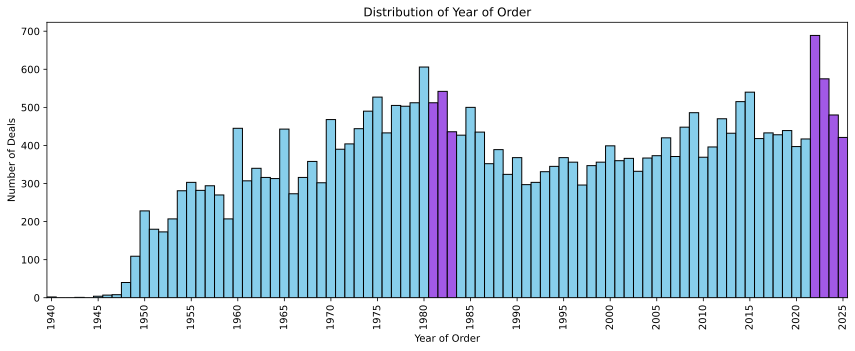

In [120]:
# Drop missing or NaN years, convert to int if needed
years = arms_df["Year of order"].dropna().astype(int)

# Get unique years for full range, for ticks and highlighting
min_year, max_year = years.min(), years.max()

# Define bins so each year is a bin of size 1
bins = np.arange(min_year, max_year + 2, 1)  # right edge exclusive

fig, ax = plt.subplots(figsize=(12, 5))
n, bins_, patches = ax.hist(years, bins=bins, color='skyblue', edgecolor='black', align='mid')

# Highlight the periods 1981-83 and 2022-25
for patch, left_edge, right_edge in zip(patches, bins_[:-1], bins_[1:]):
    bin_year = int(left_edge)
    # highlight relevant periods
    if (1981 <= bin_year <= 1983) or (2022 <= bin_year <= 2025):
        patch.set_facecolor('#a259e6')  # purple


# Set title and labels
ax.set_title("Distribution of Year of Order")
ax.set_xlabel("Year of Order")
ax.set_ylabel("Number of Deals")

# Only show ticks for years divisible by five (ending in 0 or 5)
tick_years = [year for year in bins_[:-1] if int(year) % 5 == 0 or int(year) % 5 == 5]
tick_centers = [y + 0.5 for y in tick_years]
ax.set_xticks(tick_centers)
ax.set_xticklabels([str(int(y)) for y in tick_years], rotation=90)
ax.set_xlim(bins_[0], bins_[-1])

plt.tight_layout()
plt.show()

Looking at the distribution of weapons deals per year, I saw a sharp bump around 2022 following Russia's invasion of Ukraine. The period could be interesting to compare to an earlier 'antagonistic' moment such as the Cold War. A [quick Google search](https://www.britannica.com/event/Cold-War) suggested that the period from 1981-83 could provide a good match as one of the 'heights' of the Cold War given renewed tensions between the U.S. and the USSR. For my project, I'll thus compare network structures and relationship nuances during these two periods.

# 3) Building a graph
(_The first few cells here are again drawn from the provided weapons notebook._)

In [18]:
flowmap_arms_df = arms_df[~arms_df["Supplier"].isin(exclude_flows) & ~arms_df["Recipient"].isin(exclude_flows)].rename(
    columns={
        "Year of order": "order_year",
        "Recipient": "recipient",
        "Supplier": "supplier",
        "SIPRI TIV for total order": "order_sipri_tiv"
    }
)
# Convert the order_year column to datetime (year)
flowmap_arms_df["order_year"] = pd.to_datetime(flowmap_arms_df["order_year"], errors="coerce", format="%Y")


def period_slice(df, start_year, end_year):
    start = pd.to_datetime(str(start_year), format="%Y")
    end = pd.to_datetime(str(end_year), format="%Y")
    return df[df["order_year"].between(start, end)].copy()


flowmap_arms_df_og = period_slice(flowmap_arms_df, 1981, 1983)
flowmap_arms_df_new = period_slice(flowmap_arms_df, 2022, 2025)

In [19]:
orders_by_year_df = flowmap_arms_df.groupby(["order_year", "recipient", "supplier"]).sum()["order_sipri_tiv"]
orders_by_year_df

order_year  recipient      supplier      
1940-01-01  Brazil         United Kingdom    356.00
                           United States      12.00
1943-01-01  Switzerland    Sweden            105.30
1945-01-01  Australia      United Kingdom    377.10
            Canada         United States       9.00
                                              ...  
2025-01-01  United States  Sweden              0.00
            Uruguay        Brazil              0.56
                           Italy               2.00
            Uzbekistan     Turkiye             0.00
            Viet Nam       South Korea       150.00
Name: order_sipri_tiv, Length: 15762, dtype: float64

Finally, let's move on to the actual content of my project. Given the timeframes selected earlier, I visualize the transfer networks for two order-year windows: `flowmap_arms_df_og` (1981–1983) and `flowmap_arms_df_new` (2022–2025). Each map uses supplier-to-recipient pairs in that slice (subject to the earlier filters that built `flowmap_arms_df`), with TIV summed over the whole window per directed edge.

In [20]:
def aggregate_period_flows(df):
    """All flows in the period slice, summed by supplier to recipient."""
    return (
        df.groupby(["supplier", "recipient"], as_index=False)["order_sipri_tiv"]
        .sum()
    )


period_flow_og = aggregate_period_flows(flowmap_arms_df_og)
period_flow_new = aggregate_period_flows(flowmap_arms_df_new)

In [21]:
period_flow_og.head(10), period_flow_new.head(10)

(    supplier         recipient  order_sipri_tiv
 0    Algeria    Western Sahara            24.60
 1  Argentina          Paraguay             2.02
 2  Australia              Chad             9.20
 3  Australia         Indonesia            11.88
 4  Australia  Papua New Guinea             2.00
 5  Australia          Thailand            40.50
 6    Austria         Argentina            39.90
 7    Austria            Greece            30.00
 8    Austria              Iraq           200.00
 9    Austria            Israel             8.00,
     supplier  recipient  order_sipri_tiv
 0  Australia       Fiji             8.96
 1  Australia    Germany           175.10
 2  Australia  Indonesia             2.10
 3  Australia   Maldives             7.00
 4  Australia   Mongolia             2.60
 5  Australia  Sri Lanka             1.14
 6  Australia    Ukraine           107.12
 7    Austria  Argentina             0.60
 8    Austria    Hungary             0.60
 9    Austria    Morocco             1.2

We imported NetworkX above as `nx`.  Our graph will have directed edges FROM the supplier TO the recipient of an arms shipment.

In [22]:
def flows_to_graph(flow_df):
    g = nx.DiGraph()
    for _, row in flow_df.iterrows():
        g.add_edge(row.supplier, row.recipient, weight=row.order_sipri_tiv)
    return g


orders_graph_og = flows_to_graph(period_flow_og)
orders_graph_new = flows_to_graph(period_flow_new)

Each graph’s edges run **from supplier to recipient** for the full set of aggregated transfers in that window. On the map, edges touching `exclude_flows` are skipped—the same rule as before.

In [23]:
orders_graph_og.number_of_edges(), orders_graph_new.number_of_edges()

(483, 716)

In [24]:
def cast_point(p):
    return (p.xy[0][0], p.xy[1][0])

Let's define some helpers to help me with plotting.

In [121]:
# Defining a CRS (Equal Earth - global equal-area projection) for whole-world maps
WORLD_MAP_CRS = "EPSG:8857"  

In [112]:
def graph_node_positions(orders_graph):
    """Return projected map positions for graph nodes with known capital coordinates."""
    capitals_proj = capitals_gdf.to_crs(WORLD_MAP_CRS)
    projected_capitals = dict(capitals_proj.geometry)
    positions = {}

    for node in orders_graph.nodes():
        mapped_node = capitals_map.get(node, node)
        if mapped_node in projected_capitals:
            positions[node] = cast_point(projected_capitals[mapped_node])

    return positions

In [113]:
def filter_edges_by_percentile(orders_graph, min_percentile=0.0):
    """Return drawable weighted edges after dropping the lowest TIV edges."""
    weighted_edges = [
        (u, v, data.get("weight", 1))
        for u, v, data in orders_graph.edges(data=True)
        if u not in exclude_flows and v not in exclude_flows
    ]
    if not weighted_edges:
        return []

    min_percentile = min(max(min_percentile, 0), 1)
    weights = np.array([weight for _, _, weight in weighted_edges], dtype=float)
    threshold = np.percentile(weights, (1 - min_percentile) * 100)
    return [(u, v, weight) for u, v, weight in weighted_edges if weight >= threshold]

In [114]:
def scaled_node_sizes(node_values, nodes, node_size_scale=800, min_node_size=20):
    values = np.array([node_values.get(node, 0) for node in nodes], dtype=float)
    if len(values) == 0:
        return []
    max_value = values.max()
    if max_value <= 0:
        return np.full(len(values), min_node_size)
    return min_node_size + node_size_scale * values / max_value

Plotting the graphs for the two selected periods.

In [ ]:
def plot_period_network_map(
    orders_graph,
    title,
    *,
    min_percentile=0.0,
    node_values=None,
    node_size_scale=800,
    node_color_values=None,
    node_color="#c0392b",
    cmap="tab20",
    draw_edges=True,
    edge_width_scale=0.001,
    edge_color="blue",
):
    """Plot a period graph on world land with optional node size and color overlays."""
    fig, ax = plt.subplots(figsize=(20, 40))
    ax.axis("off")
    world_countries_gdf.to_crs(WORLD_MAP_CRS).plot(
        ax=ax,
        color="#e1f1fd",
        edgecolor="0.25",
        linewidth=0.6,
        alpha=0.75,
    )

    positions = graph_node_positions(orders_graph)

    if draw_edges:
        for u, v, weight in filter_edges_by_percentile(orders_graph, min_percentile):
            if u not in positions or v not in positions:
                continue
            nx.draw_networkx_edges(
                orders_graph,
                {u: positions[u], v: positions[v]},
                edgelist=[(u, v)],
                width=edge_width_scale * weight,
                ax=ax,
                edge_color=edge_color,
                alpha=0.6,
                arrows=True,
                arrowsize=8,
            )

    if node_values is not None or node_color_values is not None:
        drawable_nodes = [node for node in orders_graph.nodes() if node in positions]
        x = [positions[node][0] for node in drawable_nodes]
        y = [positions[node][1] for node in drawable_nodes]
        sizes = (
            scaled_node_sizes(node_values, drawable_nodes, node_size_scale=node_size_scale)
            if node_values is not None
            else np.full(len(drawable_nodes), 45)
        )

        if node_color_values is None:
            colors = node_color
            colorbar = None
        else:
            groups = pd.Series([node_color_values.get(node, -1) for node in drawable_nodes])
            group_codes = pd.Categorical(groups).codes
            colors = group_codes
            colorbar = ax.scatter(
                x,
                y,
                s=sizes,
                c=colors,
                cmap=cmap,
                edgecolors="white",
                linewidths=0.5,
                alpha=0.9,
                zorder=5,
            )
            legend = ax.legend(
                *colorbar.legend_elements(prop="colors", num="auto"),
                title="Group",
                loc="lower left",
                frameon=True,
            )
            ax.add_artist(legend)

        if node_color_values is None:
            ax.scatter(
                x,
                y,
                s=sizes,
                c=colors,
                edgecolors="white",
                linewidths=0.5,
                alpha=0.9,
                zorder=5,
            )

    ax.set_title(title)
    plt.show()

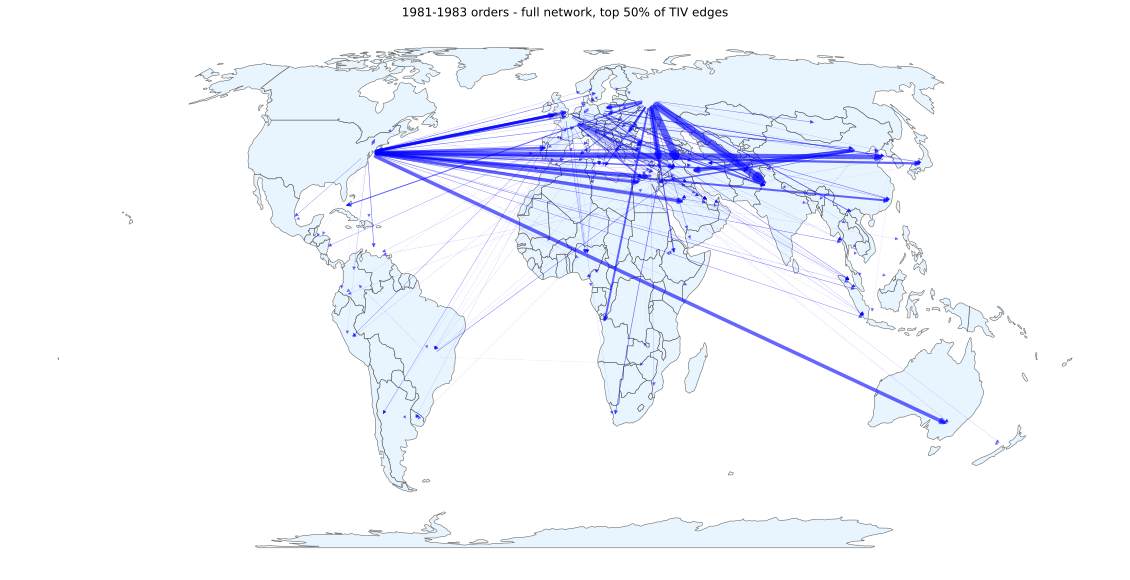

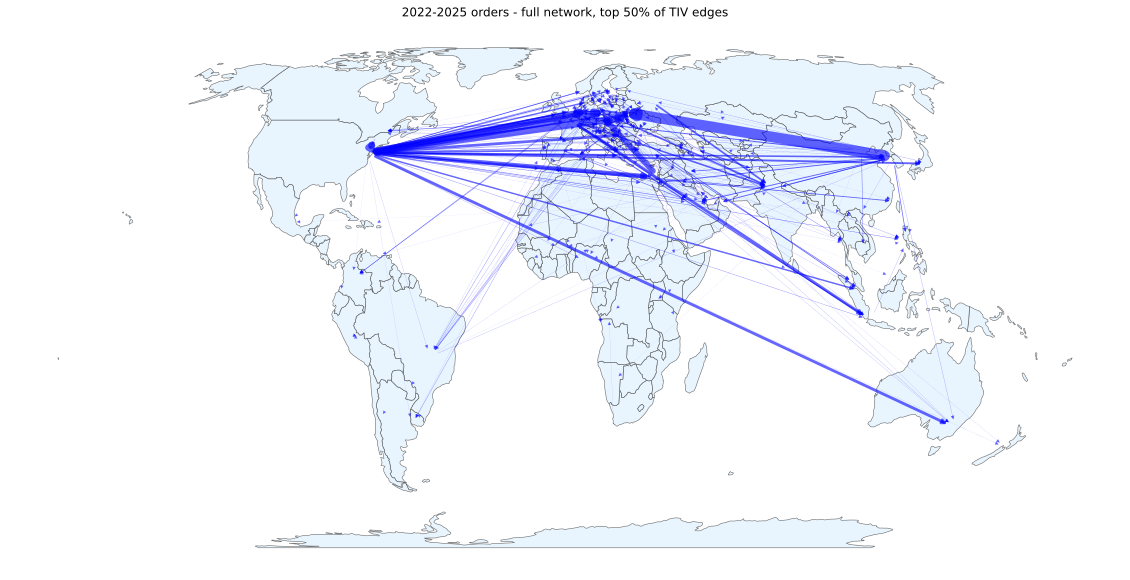

In [ ]:
# Note that the I exclude edges that are not in the top 50% of TIV edges for clarity.
plot_period_network_map(
    orders_graph_og,
    "1981-1983 orders - full network, top 50% of TIV edges",
    min_percentile=0.5, # Tune this parameter to exclude low-volume edges
)
plot_period_network_map(
    orders_graph_new,
    "2022-2025 orders - full network, top 50% of TIV edges",
    min_percentile=0.5,
)

We can see how the Russian invasion of Ukraine drastically altered the structure of arms flows. Note, too, how Russia's original position as a major exporter of weapons during the Cold War has diminished.

## FlowmapBlue

For a more interactive map that allows fuller plotting, I'll use FlowmapBlue as demonstrated in class. The sheet below has **two tabs** matching the static maps: all aggregated 1981–1983 flows and all aggregated 2022–2025 flows in each period slice.

This line will pop up a dialog asking for permission to generate Google Sheets credentials using your Google login.  If you're doing this in Colab, it should be particularly seamless.

In [32]:
period_nodes = (
    set(period_flow_og["supplier"])
    | set(period_flow_og["recipient"])
    | set(period_flow_new["supplier"])
    | set(period_flow_new["recipient"])
)

def build_flowmap_locations(nodes, sort_nodes=False, require_known=False):
    ordered_nodes = sorted(nodes) if sort_nodes else nodes
    return pd.DataFrame(
        [
            {
                "id": loc,
                "name": loc,
                "lat": capitals_gdf.loc[capitals_map.get(loc, loc), "latitude"],
                "lon": capitals_gdf.loc[capitals_map.get(loc, loc), "longitude"],
            }
            for loc in ordered_nodes
            if not require_known or capitals_map.get(loc, loc) in capitals_gdf.index
        ]
    )


flowmap_locations_df = build_flowmap_locations(period_nodes)
flowmap_locations_df.head(5)

,id,name,lat,lon
0,Rwanda,Rwanda,-1.951644,30.058586
1,New Zealand,New Zealand,-41.299988,174.783266
2,North Korea,North Korea,39.021385,125.752745
3,Nigeria,Nigeria,9.085279,7.531382
4,South Korea,South Korea,37.568295,126.997785


If you don't want to go through the whole Google permissions thing, read this [Medium article](https://medium.com/@a.marenkov/how-to-get-credentials-for-google-sheets-456b7e88c430) for info about getting credentials.

In [33]:
sheet_creds = google_sheets_credentials()

In [ ]:
flow_sheet = generate_flow_sheet(
    sheet_creds=sheet_creds,
    locations_df=flowmap_locations_df,
    created_by_name="",  # Name
    created_by_email="", # Email
    data_source_name="SIPRI Arms Transfers Database",
    data_source_url="https://www.sipri.org/databases/armstransfers",
    incoming_tooltip="Inbound arms transfers (TIV)",
    outgoing_tooltip="Outbound arms transfers (TIV)",
    flow_tooltip="Arms transfer (TIV)",
    total_unit="TIVs",
    sheet_title="SIPRI arms: full networks by period (1981–1983 vs 2022–2025)",
    flow_title="SIPRI arms transfers (orders), aggregated by supplier and recipient per period",
    flows={
        "1981–1983 (all transfers)": period_flow_og.rename(
            columns={
                "supplier": "origin",
                "recipient": "dest",
                "order_sipri_tiv": "count",
            }
        ),
        "2022–2025 (all transfers)": period_flow_new.rename(
            columns={
                "supplier": "origin",
                "recipient": "dest",
                "order_sipri_tiv": "count",
            }
        ),
    },
)

100%|██████████| 2/2 [00:12<00:00,  6.43s/it]


In [35]:
print(flow_sheet.url)

https://docs.google.com/spreadsheets/d/1U7Rd9d8jTLwBYXIkma8ABiKFPJCLv06esE4jrPmxFxU


In [36]:
print(f"https://www.flowmap.blue/{flow_sheet.url.split('/')[-1]}")

https://www.flowmap.blue/1U7Rd9d8jTLwBYXIkma8ABiKFPJCLv06esE4jrPmxFxU


# 4) Structural Features

Next, let's examine and visualize structural features of the two period graphs. The maps below keep the top 50% of TIV-weighted edges in each period so the largest flows remain visible while lower-volume edges do not overwhelm the figure.

For this analysis, I will consider two attributes:
- **Betweenness** centrality: allows us to examine countries that serve as 'brokers' in the international weapons trade network.
- **Modularity**: Determine 'communities' in the network using the Louvain community detection algorithm which determines clusters such as to maximize within- and minimize between-group flows.

In an earlier iteration of this work, I also tested the use of blockmodeling to find 'structurally equivalent' groups of nodes as an alternative to community detection. The results were scarcely illuminating, however, so I stuck to the Louvain algorithm.

## Betweenness Centrality

Betweenness centrality identifies countries that sit on many shortest paths through the directed transfer network. The calculations below are unweighted, so the measure emphasizes brokerage position rather than shipment size; node size on the maps scales with each country's score. The results show which countries served as brokers in the international arms trade networks.

In [37]:
betweenness_og = nx.betweenness_centrality(orders_graph_og, normalized=True)
betweenness_new = nx.betweenness_centrality(orders_graph_new, normalized=True)

In [38]:
# Show overview
print("1981-1983")
display(pd.Series(betweenness_og).sort_values(ascending=False).head(10))

print("2022-2025")
display(pd.Series(betweenness_new).sort_values(ascending=False).head(10))


1981-1983


,0
France,0.039638
Brazil,0.039598
United States,0.021313
Sweden,0.021127
Soviet Union,0.020880
Finland,0.018743
Germany,0.007833
Israel,0.007683
Libya,0.005494
Egypt,0.003995


2022-2025


,0
United States,0.060377
United Arab Emirates,0.031647
France,0.031546
Canada,0.028150
Turkiye,0.024501
India,0.019777
Germany,0.016476
Russia,0.012623
Saudi Arabia,0.011475
Spain,0.009177


Note France's high brokerage position during the Cold War. France famously maintained an independent arms' sale policy during the Cold War, which put it in exchange with a wide range of states and hence boosted its brokerage position. In the 21st century, the United States' hegemonic international role comfortably puts it in the top brokerage position followed by major arms dealers (e.g., France) as well as newly minted regional brokers (e.g., UAE).

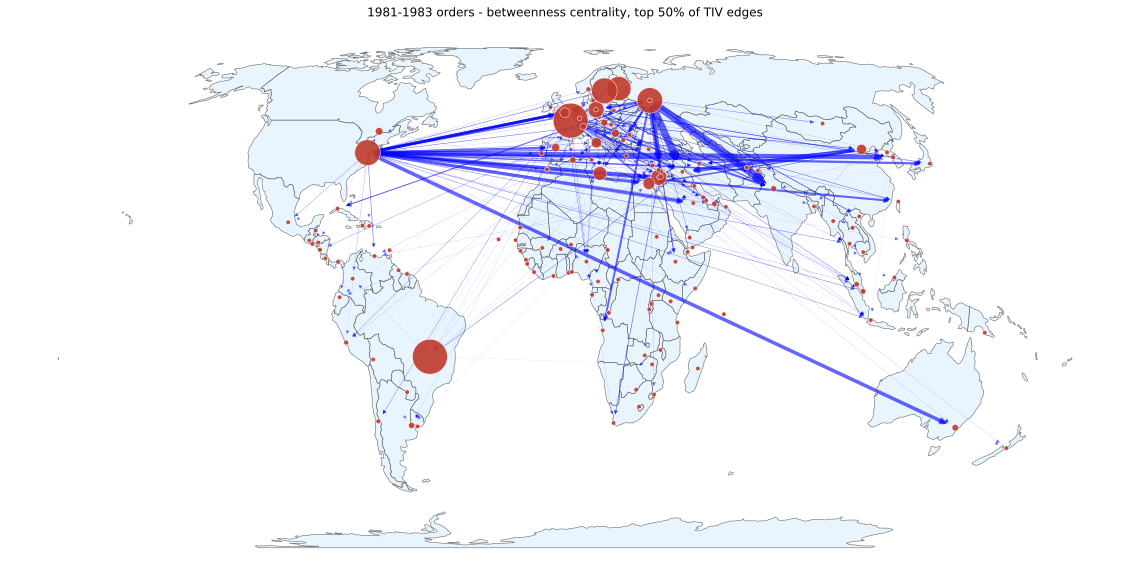

In [ ]:
plot_period_network_map(
    orders_graph_og,
    "1981-1983 orders - betweenness centrality, top 50% of TIV edges",
    min_percentile=0.5, # Again filtering the edges shown based on TIV values
    node_values=betweenness_og,
    node_size_scale=1200,
    node_color="#c0392b",
)

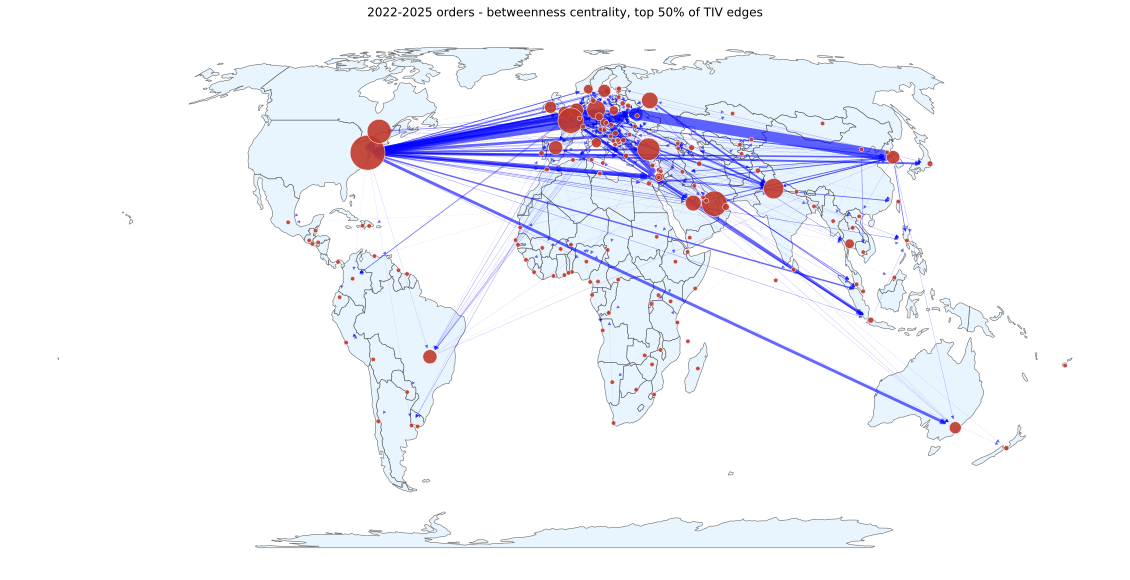

In [40]:
plot_period_network_map(
    orders_graph_new,
    "2022-2025 orders - betweenness centrality, top 50% of TIV edges",
    min_percentile=0.5,
    node_values=betweenness_new,
    node_size_scale=1200,
    node_color="#c0392b",
)

In some respects, the two periods obviously resemble each other, inviting a comparison of the Ukraine invasion to the height of the Cold War. The United States' high betweenness centrality and the concentration of brokers in Europe suggests a continuity of a 'Western' block with outsize importance in the global alliance system. Yet such an analysis ignores other features that show a marked difference: the decline of Russia (formerly USSR) as a global power broker, and the increased distribution of power from a few highly central nodes located mostly in the Western hemisphere to a more balanced distribution of brokerage across the globe. Together, the plots reveal a shift from a highly centralized and polarized world to a more multipolar setup in the 21st century, even if the actors involved in the Ukraine war (a 'Western block' versus Russia and allies) proper seem to give an illusion of repetition.

## Community Detection (Louvain)

The Louvain community detection algorithm groups countries into densely connected modules. Because NetworkX's Louvain implementation works on undirected graphs, each directed period network is converted to a weighted undirected graph before detection. TIV weights define tie strength throughout this section.

In [47]:
def period_louvain_graph(orders_graph, weight="weight"):
    undirected_graph = nx.Graph()
    undirected_graph.add_nodes_from(orders_graph.nodes())

    for u, v, data in orders_graph.edges(data=True):
        edge_weight = data.get(weight, 1)
        if undirected_graph.has_edge(u, v):
            undirected_graph[u][v][weight] += edge_weight
        else:
            undirected_graph.add_edge(u, v, **{weight: edge_weight})

    return undirected_graph


def louvain_partition(orders_graph, resolution=1.0, weight="weight", seed=42):
    undirected_graph = period_louvain_graph(orders_graph, weight=weight)
    communities = nx.community.louvain_communities(
        undirected_graph,
        weight=weight,
        resolution=resolution,
        seed=seed,
    )
    return {node: community_id for community_id, community in enumerate(communities) for node in community}


def communities_from_partition(partition):
    communities = {}
    for node, group in partition.items():
        communities.setdefault(group, set()).add(node)
    return list(communities.values())

In [48]:
louvain_og_weighted = louvain_partition(orders_graph_og, resolution=1.0)
louvain_new_weighted = louvain_partition(orders_graph_new, resolution=1.0)

In [49]:
def node_weighted_degree(orders_graph):
    """Return total incident TIV for each node in a directed period graph."""
    weighted_degree = {node: 0 for node in orders_graph.nodes()}
    for u, v, data in orders_graph.edges(data=True):
        weight = data.get("weight", 1)
        weighted_degree[u] += weight
        weighted_degree[v] += weight
    return weighted_degree

In [50]:
def world_country_name_column():
    candidates = ["ADMIN", "NAME", "NAME_LONG", "SOVEREIGNT", "adm0name", "name"]
    for column in candidates:
        if column in world_countries_gdf.columns:
            return column
    raise ValueError("Could not find a country-name column in world_countries_gdf.")


def normalize_country_name(country_name):
    return "".join(ch.lower() for ch in str(country_name) if ch.isalnum())


def polygon_country_name(country_name):
    name_column = world_country_name_column()
    world_names = set(world_countries_gdf[name_column].dropna())
    normalized_lookup = {normalize_country_name(name): name for name in world_names}
    overrides = {
        "Bosnia-Herzegovina": "Bosnia and Herzegovina",
        "Congo (Brazzaville)": "Republic of the Congo",
        "Congo (Kinshasa)": "Democratic Republic of the Congo",
        "Cote d'Ivoire": "Ivory Coast",
        "Czech Republic": "Czechia",
        "North Macedonia": "Macedonia",
        "South Korea": "Republic of Korea",
        "United States": "United States of America",
    }

    for candidate in [overrides.get(country_name, country_name), country_name]:
        if candidate in world_names:
            return candidate
        normalized = normalize_country_name(candidate)
        if normalized in normalized_lookup:
            return normalized_lookup[normalized]

    return country_name

In [51]:
def country_group_assignments(orders_graph, partition):
    """Assign country polygons to groups, resolving conflicts by largest weighted degree."""
    weighted_degree = node_weighted_degree(orders_graph)
    rows = []

    for node, group in partition.items():
        if node in exclude_flows:
            continue
        country = capitals_map.get(node, node)
        rows.append(
            {
                "country": polygon_country_name(country),
                "node": node,
                "group": group,
                "weighted_degree": weighted_degree.get(node, 0),
            }
        )

    if not rows:
        return pd.DataFrame(columns=["country", "node", "group", "weighted_degree"])

    return (
        pd.DataFrame(rows)
        .sort_values(["country", "weighted_degree"], ascending=[True, False])
        .drop_duplicates("country", keep="first")
    )

In [53]:
diag_og_weighted = {
    "period": "1981-1983",
    "resolution": 1.0,
    "communities": len(set(louvain_og_weighted.values())),
    "modularity": nx.community.modularity(
        period_louvain_graph(orders_graph_og),
        communities_from_partition(louvain_og_weighted),
        weight="weight",
        resolution=1.0,
    ),
}

diag_new_weighted = {
    "period": "2022-2025",
    "resolution": 1.0,
    "communities": len(set(louvain_new_weighted.values())),
    "modularity": nx.community.modularity(
        period_louvain_graph(orders_graph_new),
        communities_from_partition(louvain_new_weighted),
        weight="weight",
        resolution=1.0,
    ),
}

louvain_diagnostics = pd.DataFrame([diag_og_weighted, diag_new_weighted])
louvain_diagnostics

,period,resolution,communities,modularity
0,1981-1983,1.0,4,0.441500
1,2022-2025,1.0,7,0.316079


A quick note on modularity scores, wich help us gauge the quality of the detected communities (i.e., how segregated and internally connected they are). Not shown here is a grid search over resolution values I used to determine how 'coarse' the communities detected by the algorithm should be. I settled on a value of 1, which provided a strong plateau with reasonable modularity scores across both periods. A score of 0.44 for 1981-1983 is fairly strong, and reflects the fact that the Cold War network really did have sharp bloc structure with dense within-bloc trading and sparse cross-bloc trading. A score for 0.32 for 2022-2025 is moderate-to-good and derives from a more multipolar and entangled post-Cold War arms trade regime. As countries like India, Saudi Arabia, or Egypt increasingly buy from multiple blocs, community boundaries naturally bleed and modularity drops in consequence.

In this sense, the drop from 0.44 to 0.32 across the two periods is itself worth noting, as it quantifies the structural shift from a bipolar to a more diffuse global arms trade network.

In [ ]:
def plot_group_choropleth(orders_graph, partition, title, cmap="tab20"):
    """Plot country polygons colored by community."""
    name_column = world_country_name_column()
    assignments = country_group_assignments(orders_graph, partition)
    choropleth_gdf = world_countries_gdf.merge(
        assignments[["country", "group"]],
        left_on=name_column,
        right_on="country",
        how="left",
    )
    choropleth_gdf["group_label"] = choropleth_gdf["group"].apply(
        lambda group: f"Group {int(group)}" if pd.notna(group) else np.nan
    )

    fig, ax = plt.subplots(figsize=(20, 10))
    choropleth_gdf.to_crs(WORLD_MAP_CRS).plot(
        column="group_label",
        categorical=True,
        cmap=cmap,
        ax=ax,
        legend=True,
        edgecolor="0.25",
        linewidth=0.5,
        missing_kwds={"color": "#f2f2f2", "edgecolor": "0.7", "label": "No group"},
        legend_kwds={"loc": "lower left"},
    )
    ax.axis("off")
    ax.set_title(title)
    plt.show()

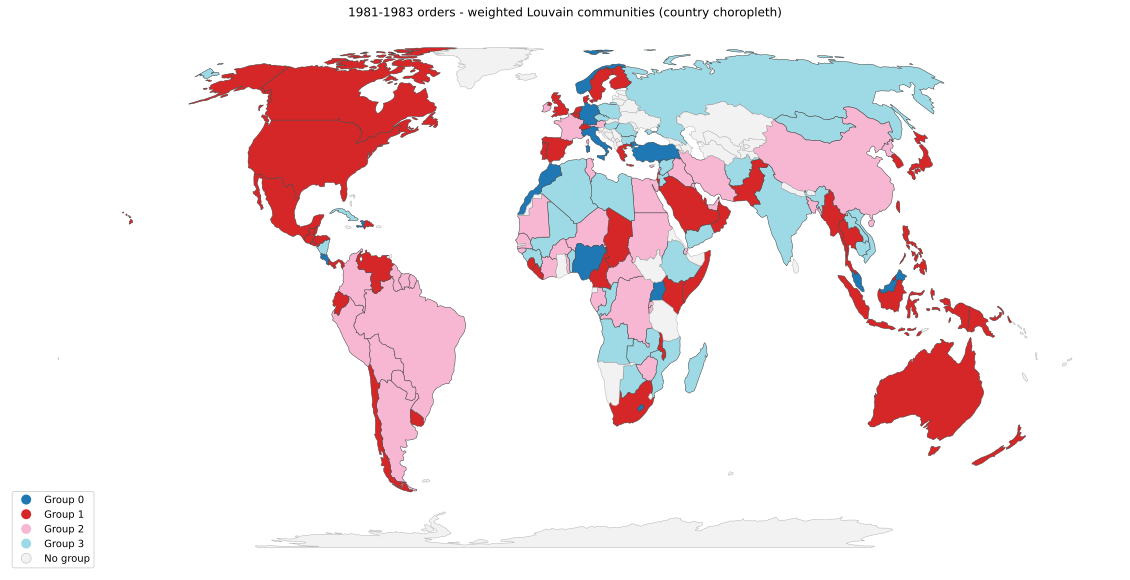

In [141]:
plot_group_choropleth(
    orders_graph_og,
    louvain_og_weighted,
    "1981-1983 orders - weighted Louvain communities (country choropleth)",
    cmap="tab20",
)

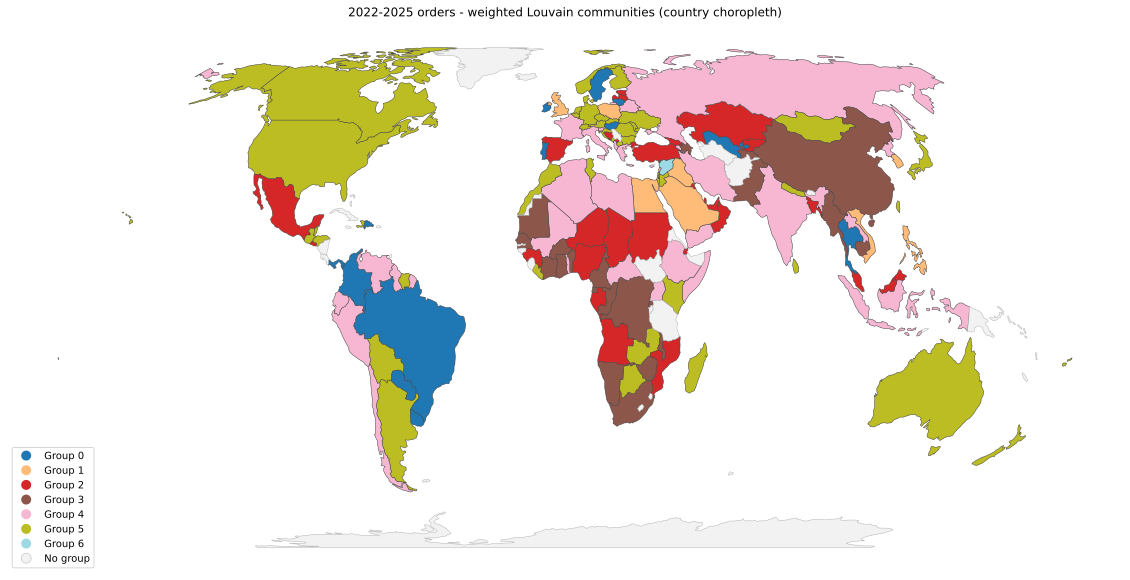

In [142]:
plot_group_choropleth(
    orders_graph_new,
    louvain_new_weighted,
    "2022-2025 orders - weighted Louvain communities (country choropleth)",
    cmap="tab20",
)

For your interpretation (and my later plots), I have grouped these into the following categories:

**1981-1983 groupings:**
- 0: French sphere (or: independent exporters & clients)
- 1: Western / NATO bloc
- 2: Non-aligned & secondary recipients
- 3: Soviet / Eastern bloc

**2022-2025 groupings:**
- 0: Latin American cluster
- 1: Gulf states
- 2: Ukraine war recipients & Eastern European frontline states
- 3: Chinese sphere (Africa & Asia)
- 4: Independent global actors
- 5: Western suppliers coalition (Anglosphere & NATO core)
- 6: Syria (isolated)

The groups might seem somewhat confusing, especially in the 2020s, but again underscore the fracturing of power across a multipolar world order after the end of the original Cold War. In the 2020s, China's solidifying presence in Africa is noteworthy, as is Latin America's increased independence. Group 4 might here seem especially confusing, comprising states as varied as France, India, Somalia, and Russia. Some of this mix-up can be attributed to India's notable independent position during the Russia-Ukraine conflict alongside France's continuation of an independent global arms trade policy. These roles may inadvertently place the countries in a hodgepodge group of states including Russia despite a lack of formal agreement or support in other terms.

# 5) NLP for Tie Quality
Now let's move toward a clearer picture of the "Comments" column that could help us provide insights into the 'content' or 'quality' of ties. Upon investigation, I determined that the comments could yield insights into two aspects of arms trading. The prevalence of **aid** and the **purpose** for which arms are meant to be used. Aid is straightfoward to detect: it simply involves the presence of "aid" as a comment. The comments sometimes include additional nuance, but the underlying approach in these cases will be the same: using regex to classify whether the comments describes a tie as 'aid' or not.

The purpose for which the arms are transferred is a bit more nuanced. Often, comments will include a phrase describing the intended use of the weapons traded as "for ...". In many cases, the link is simply another weapons system - for example, when a type of missile is bought "for use with [insert missile launcher name]." Yet in other cases, these may describe the agency or types of operations a system is planned for. We can again use regex to extract these for-clauses, though with added details to make sense of edge cases such as the presence of multiple for-clauses.

## Aid

In [57]:
# Define aid
flowmap_arms_df["aid"] = flowmap_arms_df["Comments"].str.contains(r"\baid\b", case=False, na=False)

In [129]:
# Inspect if aid is correctly extracted (cycle through different random_states to see different rows); or set "aid" to False
pd.set_option('display.max_colwidth', None)
aid_sample_df = flowmap_arms_df[flowmap_arms_df["aid"] == True].sample(n=30, random_state=42)[["recipient", "supplier", "order_year", "Comments", "aid"]]
display(aid_sample_df)
# Reset max_colwidth to default (50)
pd.reset_option('display.max_colwidth')

,recipient,supplier,order_year,Comments,aid
27305,Ukraine,Belgium,2023-01-01,Second-hand; aid after 2022 Russian invasion of Ukraine; F-16AM version (incl some F-16BM/F-16D); delivery planned 2026-2028,True
14775,Lebanon,France,1981-01-01,Second-hand; aid; 'Messidor' deal,True
17561,Nicaragua,Soviet Union,1988-01-01,Probably second-hand; probably aid for use against Contra rebels,True
27172,Ukraine,Belgium,2022-01-01,Second-hand; financed by aid from United Kingdom after 2022 Russian invasion of Ukraine,True
21878,Senegal,France,1984-01-01,Aid,True
20534,Portugal,Germany,1993-01-01,Second-hand; 5 more for spares only; aid,True
27279,Ukraine,Estonia,2022-01-01,Second-hand; aid after 2022 Russian invasion of Ukraine,True
2767,Botswana,United States,2024-01-01,Second-hand; aid,True
25943,Thailand,United States,1964-01-01,'MAP' aid; incl 4 RF-5A reconnaissance and 2 F-5B trainer/combat version,True
2956,Brazil,United States,1958-01-01,Second-hand; 'MAP' aid; F-80C version,True


We can already see that a lot of 'Aid' seems to have come after the 2022 Russian invasion of Ukraine. We can also see how a lot of aid seems to involve second-hand weapons systems. Though I won't investigate the latter point further, it's worth considering if we were to think about how weapons flow downstream through multiple rounds of exchange.

## "For..." Extraction (Regex)
The second step consists of extracting the stated reasons for the arms trade. These are described using "for ..." in the comments section. We can use simple regex rules to extract these, though note we have to be careful about the presence of multiple such for-clauses in the comments. Setting up these regexes and edge cases required careful qualitative inspection of the data and multiple rounds of iterative testing/quality assurance.

In [59]:
len(flowmap_arms_df[flowmap_arms_df["Comments"].str.contains(r"\bfor\b", case=False, na=False)])

9550

Though by far not all edges contain a Comment with a for-clause, about a third do. That should be sufficient for us to attempt grouping them into different 'types' of clauses using topic modeling and using these clusters in a downstream analysis. A look at these comments should give us some idea of how we have to process the text data for topic modeling.

In [60]:
# Inspect cases where "for" appears as a standalone word in the "Comments" column (prompt engineering)
pd.set_option('display.max_colwidth', None)
for_comments_sample_df = flowmap_arms_df[flowmap_arms_df["Comments"].str.contains(r"\bfor\b", case=False, na=False)].sample(n=30, random_state=42)[["recipient", "supplier", "order_year", "Comments"]]
display(for_comments_sample_df)
# Reset max_colwidth to default (50)
pd.reset_option('display.max_colwidth')

,recipient,supplier,order_year,Comments
15225,Lithuania,United States,2016-01-01,For 2 NASAMS SAM systems from Norway
4900,China,France,1986-01-01,For 2 Type-052 (Luhu) and 1 Type-051B (Luhai) destroyers; and 2 Type-054 (Jiangkai-1) and 8 Type-053H3 (Jiangwei-2) frigates produced in China and for modernization of 3 Type-051 (Luda-1 and/or Luda-2) destroyers; probably assembled/produced under licence in China incl as Type-345; for use with Crotale EDIR (Chinese designation HQ-7) SAM system
28295,United Kingdom,Germany,2019-01-01,Part of GBP183 m ($238 m) deal; for UK company for training UK armed forces in 'MFTS' programme; UK designation Jupiter HT-1
25014,Taiwan,United States,1982-01-01,For F-5E combat aircraft; AIM-9J version
18037,North Korea,China,1973-01-01,For Soho frigate and Huangfen missile boats and for coastal defence
18242,Norway,United Kingdom,1989-01-01,Part of $18 m deal (incl modernization of 10 Norwegian Sea Kings to Mk-43B version); Sea King Mk-43B version; for SAR
24513,Sweden,United Kingdom,1992-01-01,Second-hand; for use as depot ship; Swedish designation Belos-3
5491,Croatia,Israel,2017-01-01,HRK94 m ($14.8 m) deal; UT-30MK2 version for 6 AMV infantry fighting vehicles from Finland
25749,Thailand,United Kingdom,2008-01-01,16RK-270 (6700hp) diesel engine; for 1 Endurance landing ship from Singapore
7297,Egypt,China,1976-01-01,Exchanged for several MiG-23 fighter aircraft used by China for development of Chinese fighter aircraft


Some notes on the extraction of for clauses:

Since some comments include multiple such 'for ...' clauses, I break these up into individual clauses. That helps us group them into categories during topic modeling, which will treat each individual for-clause as a 'document' belonging to a particular topic. With these multiple clauses in tow, we can also better approximate the complexity in international arms trade relations in line with the literature reviewed earlier.

Additionally, numerous comments include mentions of countries and their adjectives, which may refer to the weapons' origins, manufacturing country, or contexts of deployment. These would clutter our topic model, which clusters comments based on the content of their contents and could identify country names as topics simply due to their frequent recurrence.

As a result, my extraction of for-clauses below includes a data-cleaning step with SpaCy's named entity recogntion (NER) capacities. Passing each comment to SpaCy slightly increases runtime, but let's us filter out words that are tagged as ``GPE`` (geopolitical: countries/cities/regions) or ``NORP`` (nationalities/demonyms/adjectives). For more details, consider the SpaCy documentation [here](https://spacy.io/usage/linguistic-features#named-entities).

In [ ]:
# Load SpaCy model. Entities: GPE (geopolitical: countries/cities/regions); NORP (nationalities/demonyms/adjectives).
nlp = spacy.load("en_core_web_sm")
GEO_OR_DEMONYM_LABELS = frozenset({"GPE", "NORP"})

# Define regexes and helpers to extract individual for-clauses
FOR_CLAUSE_START_RE = re.compile(r"\bfor\b", flags=re.IGNORECASE)
SEMICOLON_RE = re.compile(r";")
TRAILING_CONNECTOR_RE = re.compile(r"\s+and\s*$", flags=re.IGNORECASE)
WHITESPACE_RE = re.compile(r"\s+")


def strip_gpe_norp_tokens(text):
    '''Drop tokens spaCy assigns as GPE or NORP.'''
    doc = nlp(text)
    kept = [tok.text for tok in doc if tok.ent_type_ not in GEO_OR_DEMONYM_LABELS]
    return WHITESPACE_RE.sub(" ", " ".join(kept)).strip()


def clean_reason_text(reason):
    '''Normalize one extracted for-clause; remove NORP/GPE-labelled words via spaCy NER.'''
    if not isinstance(reason, str):
        return None

    reason = WHITESPACE_RE.sub(" ", reason).strip(" ,.;:")
    reason = TRAILING_CONNECTOR_RE.sub("", reason).strip(" ,.;:")
    if not reason:
        return None

    reason = strip_gpe_norp_tokens(reason).strip(" ,.;:")
    return reason or None


def extract_for_reasons(comment):
    '''Return each standalone for-clause up to the next for, semicolon, or comment end.'''
    if not isinstance(comment, str):
        return []

    matches = list(FOR_CLAUSE_START_RE.finditer(comment))
    reasons = []

    for idx, match in enumerate(matches):
        start = match.end()
        next_for_start = matches[idx + 1].start() if idx + 1 < len(matches) else len(comment)
        semicolon_match = SEMICOLON_RE.search(comment, pos=start, endpos=next_for_start)
        end = semicolon_match.start() if semicolon_match else next_for_start

        reason = clean_reason_text(comment[start:end])
        if reason:
            reasons.append(reason)

    return reasons


In [62]:
# Extract clauses from "Comments" column; takes about 1min to run
flowmap_arms_df["for_reasons"] = flowmap_arms_df["Comments"].apply(extract_for_reasons)

# Keep repeated runs tidy by replacing any earlier reason_* columns.
old_reason_cols = [col for col in flowmap_arms_df.columns if re.fullmatch(r"reason_\d+", str(col))]
flowmap_arms_df = flowmap_arms_df.drop(columns=old_reason_cols)

max_reasons = flowmap_arms_df["for_reasons"].str.len().max()
max_reasons = 0 if pd.isna(max_reasons) else int(max_reasons)
reason_column_names = [f"reason_{idx}" for idx in range(1, max_reasons + 1)]

reason_cols_df = pd.DataFrame(
    flowmap_arms_df["for_reasons"].tolist(),
    index=flowmap_arms_df.index,
    columns=reason_column_names,
)

flowmap_arms_df = pd.concat([flowmap_arms_df, reason_cols_df], axis=1)

In [63]:
# Inspect the extracted for-clauses
reason_preview_cols = [col for col in flowmap_arms_df.columns if re.fullmatch(r"reason_\d+", str(col))]
rows_with_reasons = flowmap_arms_df["for_reasons"].str.len().gt(0).sum()

print(f"Rows with at least one extracted for-clause: {rows_with_reasons:,}")
print(f"Maximum number of for-clauses in one comment: {len(reason_preview_cols)}")

preview_cols = ["recipient", "supplier", "order_year", "Comments", *reason_preview_cols]
preview_pool = flowmap_arms_df[flowmap_arms_df["for_reasons"].str.len().gt(0)]

# Prioritize multi-clause examples because they are the hardest cases to validate by eye.
multi_clause_preview = preview_pool[preview_pool["for_reasons"].str.len().gt(1)]
if len(multi_clause_preview) > 0:
    display(multi_clause_preview[preview_cols].sample(n=min(10, len(multi_clause_preview)), random_state=42))
else:
    display(preview_pool[preview_cols].sample(n=min(10, len(preview_pool)), random_state=42))

Rows with at least one extracted for-clause: 9,496
Maximum number of for-clauses in one comment: 4


,recipient,supplier,order_year,Comments,reason_1,reason_2,reason_3,reason_4
22294,Singapore,Israel,1992-01-01,For 6 MGB-62 (Victory) corvettes from FRG; for...,6 MGB-62 ( Victory ) corvettes from FRG,use with Barak SAM,None,None
3887,Canada,Thailand,2024-01-01,Second-hand; for civilian company for training...,civilian company,training of and other forces,None,None
24480,Sweden,United States,1979-01-01,For target-towing and EW training; operated by...,target - towing and EW training,armed forces,None,None
16125,Mexico,Brazil,2001-01-01,Part of $230-250 m deal; incl for SIGINT; main...,SIGINT,anti - narcotics operations,None,None
10346,India,France,2017-01-01,EUR7.8 b deal (incl EUR5.2 b for aircraft EUR1...,aircraft EUR1.8 b,spare parts and EUR710 m,armament,None
13405,Japan,United States,1978-01-01,For frigates and destroyers; UGM-84 version fo...,frigates and destroyers,submarines and AGM-84 version,P-3C anti - submarine aircraft,None
10857,India,Israel,2000-01-01,For modernization of 1 Viraat aircraft carrier...,modernization of 1 Viraat aircraft carrier,3 Brahmaputra frigates produced in,use with Barak-1 SAM system,None
6224,Denmark,United Kingdom,1982-01-01,For 4 Thetis frigates and 7 Flyvefisken missil...,4 Thetis frigates and 7 Flyvefisken missile bo...,modernization of 1 Beskytteren patrol ship,None,None
28260,United Kingdom,United States,1983-01-01,Second-hand; owned and operated by civilian co...,EW training and target - towing,armed forces,None,None
2699,Bolivia,Canada,1977-01-01,Second-hand; T-33AN (CT-133) version; partly e...,6 second - hand P-51D combat aircraft,private company,None,None


## BERTopic

Although many algorithms/approaches to topic modeling exist, I have chosen to use the embeddings-based BERTopic for this project ([awesome documentation here](https://maartengr.github.io/BERTopic/index.html)).

The reasons for that are:
- the module's ability to render comments of any length/complexity into a high-dimensional embedding representation, which should flatten out differences in comment complexities/lengths;
- the possibility of tuning any of the steps used in the pipeline (e.g., dimension reduction and clustering) to suit the short length of comments overall; and
- the host of functionalities included in the BERTopic package that make working with and refining topics relatively straightforward.

Our topic model will essentially treat each _individual_ for clause extracted above as a single document; embed it in a high-dimensional embedding space; reduce the dimensions with the UMAP dimension reduction algorithm; find clusters of clauses using the HBDScan clustering method; and finally provide textual representations of these clusters based on words that are unique to the documents within them (vs. the rest of the corpus).

In [64]:
# Long format: one row per extracted for-clause, keyed by original dataframe index
# (merge back with flowmap_arms_df on row_id vs index)
clause_docs_df = flowmap_arms_df[["for_reasons"]].copy()
clause_docs_df["row_id"] = clause_docs_df.index
clause_docs_df = clause_docs_df.explode("for_reasons", ignore_index=True).rename(columns={"for_reasons": "clause_text"})
clause_docs_df = clause_docs_df.dropna(subset=["clause_text"])
clause_docs_df = clause_docs_df[clause_docs_df["clause_text"].str.strip().ne("")]

print(f"Clause-level documents for BERTopic: {len(clause_docs_df):,}")
print(f"Unique deal rows contributing at least one clause: {clause_docs_df['row_id'].nunique():,}")

docs = clause_docs_df["clause_text"].astype(str).tolist()

clause_docs_df.head()

Clause-level documents for BERTopic: 10,008
Unique deal rows contributing at least one clause: 9,496


,clause_text,row_id
0,training of crews and instructors in,0
7,26 L-39 trainer aircraft from,7
8,Mi-24 combat helicopters,8
19,S-125 air - defence systems,19
40,reconnaissance role before delivery,40


In [ ]:
# Guided topic modeling would allows us to supply seed-word lists to bias clusters toward hypotheses
# The lists below could be used to guide topic modeling, but I've decided to refrain from their use in the actual model

# seed_topic_list = [
#     ["combat", "frigates", "minesweepers", "minelayers", "mfts"], # combat systems
#     ["sam", "mm", "nuclear", "warheads", "tectran", "fire"], # missile systems
#     ["training", "police", "guard", "company", "coast", "guard", "narcotics", "survey", "reconnaissance", "target", "towing"], # domestic use
#     ["vip", "transport", "government", "sar"], # transport, search-and-rescue
#     ["against", "rebels", "peacekeeping", "un"] # civil wars/peacekeeping
# ]

There are different models available to convert our text data into embeddings. Here, I have chosen a version of BERTopic's baseline (sentence-transformers/all-MiniLM-L6-v2) that was fine-tuned to military text data and should therefore be more attuned to distinguishing semantics in military language ([model card](https://huggingface.co/bbmb/deep-learning-for-embedding-model-ssilwal-qpham6_army_doc)).

**WARNING**: Due to residual stochasticity in some of BERTopics underlying steps, I could not set up a fully reproducible pipeline for this topic modeling steps despite pre-defining random states wherever I could. If you ran this yourself, your results would differ slightly from the current outputs in terms of the exact topics found and the way that documents (i.e., for-clauses) are classified. This would also cause issues downstream, where I've defined the way that these topics should be merged and named in plotting. So I'd advise against re-running this, though if you wanted to you'd also have to redo the merging and naming sections below. Sorry about that!

In [ ]:
# Set N of topics we aim to have. I set 20 for now for granularity and will refine the topics by hand below.
N_TOPICS = 20

# Define our UMAP/HDBSCAN instances for dimension reduction and clustering, respectively
umap_model_army = UMAP(n_neighbors=10, n_components=5, min_dist=0.0, metric="cosine", random_state=42)
hdbscan_model_army = HDBSCAN(min_cluster_size=5, min_samples=3, prediction_data=True)

# Load the model from Hugging Face: finetuned from MiniLM on Army doctrinal QA-style text
embedding_army_doc = SentenceTransformer("bbmb/deep-learning-for-embedding-model-ssilwal-qpham6_army_doc")

# Only do embeddings and UMAP if not yet existent; 
# else load previous instance for reproducibility
try:
# Subsequent runs
    embeddings = np.load("embeddings.npy")
except:
    embeddings = embedding_army_doc.encode(docs)
    np.save("embeddings.npy", embeddings)

topic_model_army_doc = BERTopic(
    umap_model=umap_model_army,
    hdbscan_model=hdbscan_model_army,
    nr_topics=N_TOPICS,
    calculate_probabilities=True,
    verbose=False,
)

topics_army, probs_army = topic_model_army_doc.fit_transform(docs, embeddings=embeddings)

clause_docs_df["topic_army_doc"] = topics_army
if probs_army is not None:
    clause_docs_df["topic_prob_army_doc"] = np.asarray(probs_army).max(axis=1).ravel()

# Show our topics
display(topic_model_army_doc.get_topic_info())



,Topic,Count,Name,Representation,Representative_Docs
0,-1,859,-1_in_produced_and_aircraft,"[in, produced, and, aircraft, from, combat, pa...",[Ratel infantry fighting vehicles and armoured...
1,0,6455,0_aircraft_from_combat_frigates,"[aircraft, from, combat, frigates, produced, i...","[3 KDX-2 frigates produced in, 4 frigates prod..."
2,1,731,1_training_police_guard_narcotics,"[training, police, guard, narcotics, forces, o...","[training, training, training]"
3,2,469,2_only_parts_spare_spares,"[only, parts, spare, spares, company, producti...","[spare parts only ), spare parts only ), spare..."
4,3,295,3_vip_transport_as_military,"[vip, transport, as, military, government, use...","[VIP transport, VIP transport, VIP transport]"
5,4,261,4_use_peacekeeping_forces_un,"[use, peacekeeping, forces, un, in, by, civili...","[UN peacekeeping forces in, use by peacekeepin..."
6,5,199,5_coast_guard_coastal_defence,"[coast, guard, coastal, defence, maritime, nav...","[coast guard, coast guard, coast guard]"
7,6,179,6_nuclear_warheads_under_control,"[nuclear, warheads, under, control, with, laun...","[use with nuclear warheads ( under control ), ..."
8,7,152,7_sar_csar_medevac_ssbn,"[sar, csar, medevac, ssbn, trident, asw, and, ...","[SAR, SAR, SAR]"
9,8,80,8_rebels_against_ltte_use,"[rebels, against, ltte, use, nla, plfo, pkk, c...","[use against LTTE rebels, use against LTTE reb..."


In [ ]:
# Show documents belonging to specific topic
docs_topic = clause_docs_df[clause_docs_df["topic_army_doc"] == 14]
display(docs_topic[["row_id", "clause_text", "topic_army_doc", "topic_prob_army_doc"]])

,row_id,clause_text,topic_army_doc,topic_prob_army_doc
451,465,financial reasons,14,1.000000
3369,3360,financial reasons ),14,0.467320
3531,3522,financial reasons,14,0.582287
6437,6407,financial reasons,14,0.584989
6465,6436,financial reasons,14,0.568286
8570,8548,financial reasons,14,0.467688
9321,9278,financial reasons ( offsets 360 % incl product...,14,0.035203
12733,12662,political reasons,14,0.429709
12747,12676,political reasons,14,0.426308
12940,12869,political reasons from production line in,14,0.347145


### Refine topics

We saw that our topic model generated a set of 20 topics with sometimes overlapping meaning. We did this so we could still have a hand in refining the topics later on. In the cells below, I merge the topics and rename them for easier interpretation.


In [ ]:
# This cell will give you an error. This is to warn you that if you're running all cells, you'll have to re-define the topics merged and names given
# to them further below.
print(

SyntaxError: incomplete input (149104261.py, line 1)

In [ ]:
# Parameters
army_topic_info = topic_model_army_doc.get_topic_info()


def _validate_topic_column_subset(topic_ids, label):
    allowed = set(army_topic_info["Topic"].astype(int).tolist())
    missing = sorted(set(topic_ids) - allowed)
    if missing:
        raise ValueError(
            f"{label} contains ids not in get_topic_info()['Topic']: {missing}. "
            f"Allowed: {sorted(allowed)!r}"
        )


# Merge: each sublist merges into the first topic id (BERTopic merge_topics format).
# That leaves us with 6 groups and one outlier category as shown below
ARMY_TOPIC_MERGE_GROUPS = [
    [-1, 12, 14, 16, 17], # outliers
    [0, 9, 13, 15], # combat systems
    [1, 5, 10, 11], # domestic (guards/police, training, surveying)
    [6, 18], # missile systems
    [4, 8], # specific wars/rebels/peacekeeping
    # 2: spares
    [3, 7] # transports (VIP/medical)
]
_validate_topic_column_subset(
    [int(t) for grp in ARMY_TOPIC_MERGE_GROUPS for t in grp],
    label="ARMY_TOPIC_MERGE_GROUPS",
)

merged_specs = [[int(t) for t in grp] for grp in ARMY_TOPIC_MERGE_GROUPS if len(grp) > 1]

if merged_specs:
    topic_model_army_doc.merge_topics(docs, merged_specs)
    topics_post_merge, probs_post_merge = topic_model_army_doc.transform(docs, embeddings=embeddings)
    clause_docs_df["topic_army_doc"] = topics_post_merge
    if probs_post_merge is not None:
        clause_docs_df["topic_prob_army_doc"] = np.asarray(probs_post_merge).max(axis=1).ravel()

display(topic_model_army_doc.get_topic_info()) # Show updated "Topic" column


,Topic,Count,Name,Representation,Representative_Docs
0,-1,964,-1_in_aircraft_produced_from,"[in, aircraft, produced, from, and, dhabi, abu...",[H-6 K bomber aircraft and Y-20A transport air...
1,0,6571,0_aircraft_from_combat_frigates,"[aircraft, from, combat, frigates, produced, i...","[MiG-21bis combat aircraft, F-5E combat aircra..."
2,1,1024,1_training_guard_police_coast,"[training, guard, police, coast, forces, opera...","[training, training, training]"
3,2,469,2_only_parts_spare_spares,"[only, parts, spare, spares, company, producti...","[spare parts only ), spare parts only ), spare..."
4,3,447,3_vip_sar_transport_use,"[vip, sar, transport, use, as, military, ship,...","[SAR and VIP transport, VIP transport and SAR,..."
5,4,341,4_use_against_rebels_in,"[use, against, rebels, in, forces, peacekeepin...","[use against rebels, use against rebels in, us..."
6,5,192,5_control_nuclear_warheads_with,"[control, nuclear, warheads, with, under, use,...","[use with nuclear warheads ( under control ), ..."


Note the new topic names defined now, which provide a high-level interpretation of the reasons given for arms trades in the SIPRI dataset's "Comments" column. 

In [ ]:
# Rename topics for simplicity
topic_dict = {
    0: "combat_systems",
    1: "domestic_use",
    2: "spares",
    3: "transport",
    4: "rebels_peacekeeping_wars",
    5: "missile_systems"
}

if topic_dict:
    topic_model_army_doc.set_topic_labels(topic_dict)

topic_info_labeled = topic_model_army_doc.get_topic_info().copy()
topic_label_lookup = dict(zip(topic_info_labeled["Topic"].astype(int), topic_info_labeled["Name"]))
topic_label_lookup.update({int(topic_id): label for topic_id, label in topic_dict.items()})

display(topic_info_labeled)


,Topic,Count,Name,CustomName,Representation,Representative_Docs
0,-1,964,-1_in_aircraft_produced_from,-1_in_aircraft_produced_from,"[in, aircraft, produced, from, and, dhabi, abu...",[H-6 K bomber aircraft and Y-20A transport air...
1,0,6571,0_aircraft_from_combat_frigates,combat_systems,"[aircraft, from, combat, frigates, produced, i...","[MiG-21bis combat aircraft, F-5E combat aircra..."
2,1,1024,1_training_guard_police_coast,domestic_use,"[training, guard, police, coast, forces, opera...","[training, training, training]"
3,2,469,2_only_parts_spare_spares,spares,"[only, parts, spare, spares, company, producti...","[spare parts only ), spare parts only ), spare..."
4,3,447,3_vip_sar_transport_use,transport,"[vip, sar, transport, use, as, military, ship,...","[SAR and VIP transport, VIP transport and SAR,..."
5,4,341,4_use_against_rebels_in,rebels_peacekeeping_wars,"[use, against, rebels, in, forces, peacekeepin...","[use against rebels, use against rebels in, us..."
6,5,192,5_control_nuclear_warheads_with,missile_systems,"[control, nuclear, warheads, with, under, use,...","[use with nuclear warheads ( under control ), ..."


## Merging with Network Data

At this point, we've got our categories together from both the 'aid' and topic extraction steps. We now have to attribute the categories of reasons given above back to the original ties in the SIPRI network data. Because a tie could have multiple for clauses, this also means that they may be attributed more than one 'reason', helping us approximate multiplexity in network relationships.

In [84]:
# Merge NLP features back to the tie-level network data.
flowmap_arms_enriched_df = flowmap_arms_df.copy()

# Add the aid flag
if "aid" not in flowmap_arms_enriched_df.columns:
    flowmap_arms_enriched_df["aid"] = flowmap_arms_enriched_df["Comments"].str.contains(r"\baid\b", case=False, na=False)

# Keep only interpretable BERTopic assignments and attach the manually defined topic labels.
non_outlier_topics = clause_docs_df.loc[
    clause_docs_df["topic_army_doc"].notna() & clause_docs_df["topic_army_doc"].ne(-1), # Remove -1 topic (overflow)
    ["row_id", "topic_army_doc"],
].copy()
non_outlier_topics["topic_id"] = non_outlier_topics["topic_army_doc"].astype(int)
non_outlier_topics["topic_label"] = non_outlier_topics["topic_id"].map(topic_label_lookup)
non_outlier_topics["topic_label"] = non_outlier_topics["topic_label"].fillna(
    non_outlier_topics["topic_id"].map(lambda topic_id: f"Topic {topic_id}")
)
non_outlier_topics["topic_col"] = non_outlier_topics["topic_label"]

# One-hot columns use the topic labels directly; append the id if labels collide.
topic_col_lookup = (
    non_outlier_topics[["topic_id", "topic_label", "topic_col"]]
    .drop_duplicates()
    .sort_values(["topic_id", "topic_label"])
    .reset_index(drop=True)
)
if topic_col_lookup["topic_col"].duplicated().any():
    topic_col_lookup["topic_col"] = topic_col_lookup.apply(
        lambda row: f"{row['topic_col']} ({int(row['topic_id'])})", axis=1
    )
    non_outlier_topics = non_outlier_topics.drop(columns="topic_col").merge(
        topic_col_lookup, on=["topic_id", "topic_label"], how="left"
    )

topic_indicator_cols = topic_col_lookup["topic_col"].tolist()

# Collapse clause-level topic assignments into tie-level topic lists.
topic_lists_by_row = non_outlier_topics.groupby("row_id").agg(
    topic_ids=("topic_id", lambda values: sorted(set(int(value) for value in values))),
    topic_labels=("topic_label", lambda values: sorted(set(str(value) for value in values))),
)

# Convert the many-to-one topic assignments into one-hot tie-level indicators.
topic_one_hot = pd.DataFrame(index=flowmap_arms_enriched_df.index)
if not non_outlier_topics.empty:
    topic_one_hot = pd.crosstab(non_outlier_topics["row_id"], non_outlier_topics["topic_col"])
    topic_one_hot = topic_one_hot.reindex(flowmap_arms_enriched_df.index, fill_value=0)
    topic_one_hot = topic_one_hot.reindex(columns=topic_indicator_cols, fill_value=0).clip(upper=1).astype(int)
else:
    for topic_col in topic_indicator_cols:
        topic_one_hot[topic_col] = 0

# Join topic lists and one-hot indicators back onto every network tie.
flowmap_arms_enriched_df = flowmap_arms_enriched_df.join(topic_lists_by_row, how="left").join(topic_one_hot, how="left")
flowmap_arms_enriched_df["topic_ids"] = flowmap_arms_enriched_df["topic_ids"].apply(
    lambda value: value if isinstance(value, list) else []
)
flowmap_arms_enriched_df["topic_labels"] = flowmap_arms_enriched_df["topic_labels"].apply(
    lambda value: value if isinstance(value, list) else []
)

# Add compact helper columns for summaries, plots, and FlowmapBlue filters.
flowmap_arms_enriched_df["n_topics"] = flowmap_arms_enriched_df["topic_labels"].str.len()
flowmap_arms_enriched_df["topic_label_text"] = flowmap_arms_enriched_df["topic_labels"].apply(
    lambda labels: "; ".join(labels) if labels else "No topic"
)
flowmap_arms_enriched_df["aid_status"] = np.where(flowmap_arms_enriched_df["aid"], "Aid", "Not aid")
flowmap_arms_enriched_df[topic_indicator_cols] = flowmap_arms_enriched_df[topic_indicator_cols].fillna(0).astype(int)

# Preview the enriched edge-quality fields before downstream analysis.
print(f"Enriched tie rows: {len(flowmap_arms_enriched_df):,}")
print(f"Rows with at least one non-outlier topic: {flowmap_arms_enriched_df['n_topics'].gt(0).sum():,}")
print(f"Topic indicator columns: {len(topic_indicator_cols):,}")
display(flowmap_arms_enriched_df[["supplier", "recipient", "order_year", "order_sipri_tiv", "aid_status", "topic_label_text", "n_topics"]].head(10))


Enriched tie rows: 29,516
Rows with at least one non-outlier topic: 8,625
Topic indicator columns: 6


,supplier,recipient,order_year,order_sipri_tiv,aid_status,topic_label_text,n_topics
0,Russia,Afghanistan,2010-01-01,17.4,Not aid,domestic_use,1
1,Russia,Afghanistan,2004-01-01,11.6,Aid,No topic,0
2,Soviet Union,Afghanistan,1960-01-01,4.0,Not aid,No topic,0
3,Soviet Union,Afghanistan,1978-01-01,250.0,Aid,No topic,0
4,Soviet Union,Afghanistan,1987-01-01,171.2,Not aid,No topic,0
5,United States,Afghanistan,2015-01-01,22.0,Not aid,No topic,0
6,United States,Afghanistan,2004-01-01,18.8,Aid,No topic,0
7,Soviet Union,Afghanistan,1977-01-01,15.6,Not aid,combat_systems,1
8,Russia,Afghanistan,2004-01-01,3.0,Not aid,combat_systems,1
9,Brazil,Afghanistan,2017-01-01,27.0,Not aid,No topic,0


The cell below provides a small sanity check of our results.

Aid classification distribution


,aid_status,n_ties,share_of_ties
0,Not aid,26425,0.895277
1,Aid,3091,0.104723


Number of non-outlier topics assigned per tie


,n_topics,n_ties,share_of_ties
0,0,20891,0.707786
1,1,8405,0.284761
2,2,211,0.007149
3,3,9,0.000305


Topic prevalence across ties


,topic_id,topic_label,n_ties,share_of_ties
0,0,combat_systems,6454,0.218661
1,1,domestic_use,982,0.033270
2,2,spares,449,0.015212
3,3,transport,441,0.014941
4,4,rebels_peacekeeping_wars,340,0.011519
5,5,missile_systems,188,0.006369


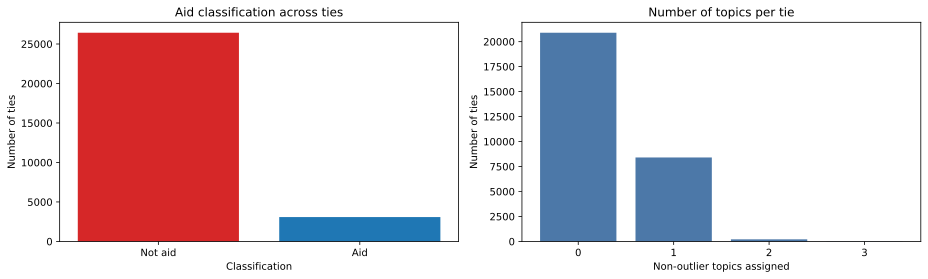

In [85]:
# Distribution checks for generated edge-quality features.
aid_distribution = (
    flowmap_arms_enriched_df["aid_status"]
    .value_counts()
    .rename_axis("aid_status")
    .reset_index(name="n_ties")
)
aid_distribution["share_of_ties"] = aid_distribution["n_ties"] / len(flowmap_arms_enriched_df)

topic_count_distribution = (
    flowmap_arms_enriched_df["n_topics"]
    .value_counts()
    .sort_index()
    .rename_axis("n_topics")
    .reset_index(name="n_ties")
)
topic_count_distribution["share_of_ties"] = topic_count_distribution["n_ties"] / len(flowmap_arms_enriched_df)

topic_prevalence = topic_col_lookup.copy()
if topic_indicator_cols:
    topic_prevalence["n_ties"] = topic_prevalence["topic_col"].map(flowmap_arms_enriched_df[topic_indicator_cols].sum())
    topic_prevalence["share_of_ties"] = topic_prevalence["n_ties"] / len(flowmap_arms_enriched_df)
    topic_prevalence = topic_prevalence.sort_values("n_ties", ascending=False)
else:
    topic_prevalence["n_ties"] = []
    topic_prevalence["share_of_ties"] = []

print("Aid classification distribution")
display(aid_distribution)
print("Number of non-outlier topics assigned per tie")
display(topic_count_distribution)
print("Topic prevalence across ties")
display(topic_prevalence[["topic_id", "topic_label", "n_ties", "share_of_ties"]])

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].bar(aid_distribution["aid_status"], aid_distribution["n_ties"], color=["#d62728", "#1f77b4"])
axes[0].set_title("Aid classification across ties")
axes[0].set_xlabel("Classification")
axes[0].set_ylabel("Number of ties")

axes[1].bar(topic_count_distribution["n_topics"].astype(str), topic_count_distribution["n_ties"], color="#4c78a8")
axes[1].set_title("Number of topics per tie")
axes[1].set_xlabel("Non-outlier topics assigned")
axes[1].set_ylabel("Number of ties")

plt.tight_layout()
plt.show()

# multi_topic_sample = flowmap_arms_enriched_df.loc[
#     flowmap_arms_enriched_df["n_topics"].gt(1),
#     ["supplier", "recipient", "order_year", "Comments", "aid_status", "topic_label_text", "order_sipri_tiv"],
# ]
# if not multi_topic_sample.empty:
#     display(multi_topic_sample.sample(n=min(10, len(multi_topic_sample)), random_state=42))


We can see that the majority of ties in fact do **not** involve aid or any of the particular reasons for the arms trade identified above. But we knew that from earlier analyses. What's important is to note that we still have several thousands such cases in our data, which should be sufficient for the purposes of this microproject (e.g., looking at edge quality in short 3-year windows).

For a broader exploration of how these edge qualities intersect with network structures, let's create some FlowmapBlue visualizations where we can interactively explore the results. The code below produces one visualization per chosen time window, each with different layers for the different kinds of ties (for-clauses) we have gained from our data processing.

In [ ]:
# Prepare FlowmapBlue layers for each project period.
def aggregate_flowmap_edges(df, category):
    flow_df = df.copy()
    flow_df["count"] = pd.to_numeric(flow_df["order_sipri_tiv"], errors="coerce").fillna(0)
    flow_df["origin"] = flow_df["supplier"]
    flow_df["dest"] = flow_df["recipient"]
    flow_df["category"] = category

    return (
        flow_df.groupby(["origin", "dest", "category"], as_index=False, dropna=False)
        .agg(
            count=("count", "sum"),
            tie_count=("count", "size"),
            aid_ties=("aid", "sum"),
        )
        .assign(not_aid_ties=lambda data: data["tie_count"] - data["aid_ties"])
        .sort_values("count", ascending=False)
        .reset_index(drop=True)
    )


def build_period_flow_layers(df, period_label):
    flows = {
        f"{period_label} - all transfers": aggregate_flowmap_edges(df, "All transfers"),
        f"{period_label} - no specified category": aggregate_flowmap_edges(
            df[df["n_topics"].eq(0)], "No specified category"
        ),
    }

    for topic_col in topic_indicator_cols:
        category_df = df[df[topic_col].eq(1)]
        if not category_df.empty:
            flows[f"{period_label} - {topic_col}"] = aggregate_flowmap_edges(category_df, topic_col)

    return flows


flowmap_arms_enriched_og = period_slice(flowmap_arms_enriched_df, 1981, 1983)
flowmap_arms_enriched_new = period_slice(flowmap_arms_enriched_df, 2022, 2025)

period_flow_layers_og = build_period_flow_layers(flowmap_arms_enriched_og, "1981-1983")
period_flow_layers_new = build_period_flow_layers(flowmap_arms_enriched_new, "2022-2025")

period_nodes = set()
for flow_layers in [period_flow_layers_og, period_flow_layers_new]:
    for flow_df in flow_layers.values():
        period_nodes.update(flow_df["origin"])
        period_nodes.update(flow_df["dest"])

flowmap_locations_df = build_flowmap_locations(
    period_nodes,
    sort_nodes=True,
    require_known=True,
)

print(f"1981-1983 FlowmapBlue layers: {len(period_flow_layers_og):,}")
print(f"2022-2025 FlowmapBlue layers: {len(period_flow_layers_new):,}")
print(f"FlowmapBlue location rows: {len(flowmap_locations_df):,}")


1981-1983 FlowmapBlue layers: 8
2022-2025 FlowmapBlue layers: 8
FlowmapBlue location rows: 177


In [87]:
# FlowmapBlue for 1980s period
# This cell will ask for Google Sheets credentials when run.
sheet_creds = google_sheets_credentials()

edge_quality_flow_sheet_1980s = generate_flow_sheet(
    sheet_creds=sheet_creds,
    locations_df=flowmap_locations_df,
    created_by_name="",
    created_by_email="",
    data_source_name="SIPRI Arms Transfers Database",
    data_source_url="https://www.sipri.org/databases/armstransfers",
    incoming_tooltip="Inbound arms transfers (TIV)",
    outgoing_tooltip="Outbound arms transfers (TIV)",
    flow_tooltip="Arms transfer (TIV)",
    total_unit="TIVs",
    sheet_title="SIPRI arms: edge-quality filters, 1981-1983",
    flow_title="SIPRI arms transfers, 1981-1983, by BERTopic edge category",
    flows=period_flow_layers_og,
)

print(edge_quality_flow_sheet_1980s.url)
print(f"https://www.flowmap.blue/{edge_quality_flow_sheet_1980s.url.split('/')[-1]}")


100%|██████████| 8/8 [01:00<00:00,  7.57s/it]

https://docs.google.com/spreadsheets/d/1BSFA9PYadbPbhYKBGO9yl8cMIlMANUzOSD1k3KkPCWs
https://www.flowmap.blue/1BSFA9PYadbPbhYKBGO9yl8cMIlMANUzOSD1k3KkPCWs


In [88]:
# FlowmapBlue for 2020s period
# This cell will ask for Google Sheets credentials when run.
sheet_creds = google_sheets_credentials()

edge_quality_flow_sheet_2020s = generate_flow_sheet(
    sheet_creds=sheet_creds,
    locations_df=flowmap_locations_df,
    created_by_name="",
    created_by_email="",
    data_source_name="SIPRI Arms Transfers Database",
    data_source_url="https://www.sipri.org/databases/armstransfers",
    incoming_tooltip="Inbound arms transfers (TIV)",
    outgoing_tooltip="Outbound arms transfers (TIV)",
    flow_tooltip="Arms transfer (TIV)",
    total_unit="TIVs",
    sheet_title="SIPRI arms: edge-quality filters, 2022-2025",
    flow_title="SIPRI arms transfers, 2022-2025, by BERTopic edge category",
    flows=period_flow_layers_new,
)

print(edge_quality_flow_sheet_2020s.url)
print(f"https://www.flowmap.blue/{edge_quality_flow_sheet_2020s.url.split('/')[-1]}")

100%|██████████| 8/8 [00:55<00:00,  6.98s/it]

https://docs.google.com/spreadsheets/d/1139AQVm6SSGSi_Gz8Dl6MMf3OCNnAWxyPJyJ90HRN-4
https://www.flowmap.blue/1139AQVm6SSGSi_Gz8Dl6MMf3OCNnAWxyPJyJ90HRN-4


It's quite fascinating to see how these edge qualities are patterned across the network in the different timeframes. Sales for transport material (search-and-rescue/high-level VIPs) tends to occur mostly within well-defined channels. Perhaps that's because such sales do not occur very often, so when they do in a given timeframe, they are linked to very particular country pairs.

Rather than expounding on each small subset of edges in the two timeframes, I'll note that the plots confirm the fact that our categories get at more specific forms of exchanges in the international arms trade system. While edges assigned to no specific cause broadly reflect the overall trade network, where countries shop across the globe for regular military development and upkeeb, selecting edges attributed to particular motivations/causes often shows very particular kinds of of countries trading for a particular purpose in the given time window. From a sociological perspective, such distinctions matter insofar as they help us identify the _types_ of relationships countries have -- an anticategorical approach to network science. Across the two timeframes, we can thus see how Russia's role in the international system declined not only as a large-scale arms dealer, but also as a purveyor of specialized arms sales. In these specialized roles, smaller countries such as Pakistan (spares) or South Korea (missile systems), have instead gained in significance.

Next, let's consider how aid changes across time and during our two periods in particular. For the plot below, I'll look at how much TIV was exchanged as part of aid, rather than taking mere edge counts - the latter would obscure the real _value_ of aid as a tool in the international weapons exchange system.

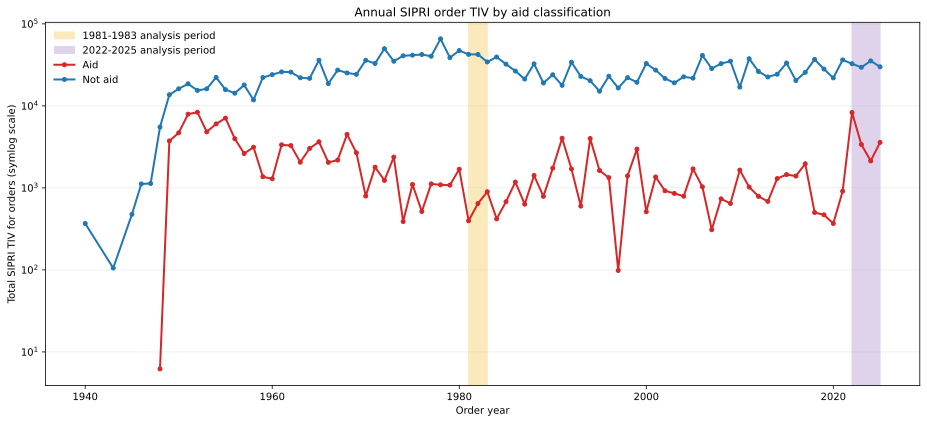

In [132]:
# TIV over time, aggregated by year and aid classification.
tiv_line_df = flowmap_arms_enriched_df.dropna(subset=["order_year", "order_sipri_tiv"]).copy()
tiv_line_df["order_year_num"] = tiv_line_df["order_year"].dt.year

tiv_by_year_aid = (
    tiv_line_df.groupby(["order_year_num", "aid_status"], as_index=False)["order_sipri_tiv"]
    .sum()
    .sort_values("order_year_num")
)

aid_colors = {"Aid": "#d62728", "Not aid": "#1f77b4"}

fig, ax = plt.subplots(figsize=(13, 6))
ax.axvspan(1981, 1983, color="#f2c94c", alpha=0.38, label="1981-1983 analysis period")
ax.axvspan(2022, 2025, color="#9467bd", alpha=0.30, label="2022-2025 analysis period")

for aid_status, group in tiv_by_year_aid.groupby("aid_status"):
    ax.plot(
        group["order_year_num"],
        group["order_sipri_tiv"],
        marker="o",
        linewidth=2,
        markersize=4,
        color=aid_colors.get(aid_status, "#7f7f7f"),
        label=aid_status,
    )

ax.set_yscale("symlog", linthresh=1)
ax.set_title("Annual SIPRI order TIV by aid classification")
ax.set_xlabel("Order year")
ax.set_ylabel("Total SIPRI TIV for orders (symlog scale)")
ax.legend(loc="upper left", frameon=False)
ax.grid(axis="y", alpha=0.25)

plt.tight_layout()
plt.show()


The plot clearly picks up the spike in aid that occurred after the start of the Russia-Ukraine conflict. The two periods compared thus seem to differ in the way that they were perceived and acted upon by the international community, with Russia's invasion of Ukraine being clearly perceived as an act inviting more benevolent support.

,topic_id,topic_label,avg_order_sipri_tiv,n_ties
2,2,spares,182.803608,449
5,5,missile_systems,126.448830,188
3,3,transport,66.111224,441
4,4,rebels_peacekeeping_wars,60.626382,340
0,0,combat_systems,48.987253,6454
1,1,domestic_use,40.479379,982


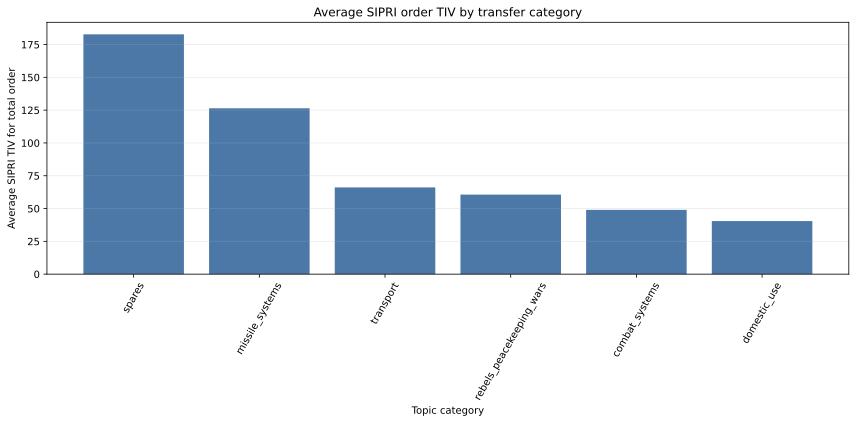

In [90]:
# Average TIV by topic category, ordered by magnitude.
average_tiv_by_topic = []
for _, topic_row in topic_col_lookup.iterrows():
    topic_col = topic_row["topic_col"]
    topic_tiv = flowmap_arms_enriched_df.loc[
        flowmap_arms_enriched_df[topic_col].eq(1), "order_sipri_tiv"
    ].dropna()
    if not topic_tiv.empty:
        average_tiv_by_topic.append(
            {
                "topic_id": int(topic_row["topic_id"]),
                "topic_label": topic_row["topic_label"],
                "avg_order_sipri_tiv": topic_tiv.mean(),
                "n_ties": len(topic_tiv),
            }
        )

avg_tiv_by_topic_df = pd.DataFrame(
    average_tiv_by_topic,
    columns=["topic_id", "topic_label", "avg_order_sipri_tiv", "n_ties"],
).sort_values("avg_order_sipri_tiv", ascending=False)

display(avg_tiv_by_topic_df)

if not avg_tiv_by_topic_df.empty:
    fig, ax = plt.subplots(figsize=(12, 6))
    ax.bar(
        avg_tiv_by_topic_df["topic_label"],
        avg_tiv_by_topic_df["avg_order_sipri_tiv"],
        color="#4c78a8",
    )
    ax.set_title("Average SIPRI order TIV by transfer category")
    ax.set_xlabel("Topic category")
    ax.set_ylabel("Average SIPRI TIV for total order")
    ax.tick_params(axis="x", rotation=60)
    ax.grid(axis="y", alpha=0.25)
    plt.tight_layout()
    plt.show()
else:
    print("No non-outlier topic assignments are available for the average TIV by topic plot.")


Finally, an analysis of TIV scores by exchange category reveals a fascinating detail: arms deals for spare sparts seem to be the most valuable on average. Weapons trading thus seems to be beneficial for seller countries in the long term when brokers are able to capitalize, both economically and politically, on the technological dependency of their buyers.

# 6) Bringing it all together

To conclude, I'll get to the original goal of my project - linking tie qualities to structural features of the arms trade network. I'll first merge the data before producing a series of exploratory plots.

In [145]:
# Combine edge quality with network structure for each comparison period.
period_structures = {
    "1981-1983": {
        "df": flowmap_arms_enriched_og,
        "partition": louvain_og_weighted,
        "betweenness": betweenness_og,
    },
    "2022-2025": {
        "df": flowmap_arms_enriched_new,
        "partition": louvain_new_weighted,
        "betweenness": betweenness_new,
    },
}

# Define substantive labels for the communities detected with the Louvain algorithm to help with plotting
community_name_overrides = {
    "1981-1983": {
        0: "Independent exporters & clients",
        1: "Western / NATO bloc",
        2: "Non-aligned & secondary recipients",
        3: "Soviet / Eastern bloc",
    },
    "2022-2025": {
        0: "Latin American cluster",
        1: "Gulf states / Mediators",
        2: "Ukraine-conflict Adjacents / Traders",
        3: "Chinese sphere (Africa & Asia)",
        4: "Independent global actors",
        5: "Western suppliers coalition",
        6: "Syria",
    },
}


def format_community_label(period_label, community_id):
    if pd.isna(community_id):
        return "No community"
    community_id = int(community_id)
    return community_name_overrides.get(period_label, {}).get(
        community_id,
        f"Community {community_id}",
    )


def betweenness_tier(score, median_cutoff, high_cutoff):
    if pd.isna(score):
        return "Unknown"
    if score >= high_cutoff:
        return "High"
    if score >= median_cutoff:
        return "Mid"
    return "Low"


def collapse_betweenness_flow(supplier_tier, recipient_tier):
    if "Unknown" in {supplier_tier, recipient_tier}:
        return "Unknown"
    if supplier_tier == "High" and recipient_tier in {"Mid", "Low"}:
        return "High->Low"
    if recipient_tier == "High" and supplier_tier in {"Mid", "Low"}:
        return "Low->High"
    return "Similar"


def add_period_structure_columns(df, period_label, partition, betweenness):
    structured = df.copy()

    structured["supplier_community"] = structured["supplier"].map(partition)
    structured["recipient_community"] = structured["recipient"].map(partition)
    structured["supplier_community_label"] = structured["supplier_community"].apply(
        lambda community_id: format_community_label(period_label, community_id)
    )
    structured["recipient_community_label"] = structured["recipient_community"].apply(
        lambda community_id: format_community_label(period_label, community_id)
    )
    structured["within_community"] = (
        structured["supplier_community"].notna()
        & structured["recipient_community"].notna()
        & structured["supplier_community"].eq(structured["recipient_community"])
    )

    structured["supplier_betweenness"] = structured["supplier"].map(betweenness)
    structured["recipient_betweenness"] = structured["recipient"].map(betweenness)

    betweenness_values = pd.Series(betweenness, dtype="float64")
    if betweenness_values.empty:
        median_cutoff = np.nan
        high_cutoff = np.nan
    else:
        median_cutoff = betweenness_values.median()
        high_cutoff = betweenness_values.quantile(0.75)

    structured["supplier_bc_tier"] = structured["supplier_betweenness"].apply(
        lambda score: betweenness_tier(score, median_cutoff, high_cutoff)
    )
    structured["recipient_bc_tier"] = structured["recipient_betweenness"].apply(
        lambda score: betweenness_tier(score, median_cutoff, high_cutoff)
    )
    structured["bc_dyad_type"] = structured["supplier_bc_tier"] + "->" + structured["recipient_bc_tier"]
    structured["bc_flow_group"] = structured.apply(
        lambda row: collapse_betweenness_flow(row["supplier_bc_tier"], row["recipient_bc_tier"]),
        axis=1,
    )
    structured["period"] = period_label

    return structured


structured_period_dfs = {
    period_label: add_period_structure_columns(
        period_info["df"],
        period_label,
        period_info["partition"],
        period_info["betweenness"],
    )
    for period_label, period_info in period_structures.items()
}

structured_period_df = pd.concat(structured_period_dfs.values(), ignore_index=True)

structure_preview = (
    structured_period_df.groupby(["period", "within_community"], dropna=False)
    .size()
    .rename("n_ties")
    .reset_index()
)
display(structure_preview)
structured_period_df[
    [
        "period",
        "supplier",
        "recipient",
        "supplier_community_label",
        "recipient_community_label",
        "within_community",
        "supplier_bc_tier",
        "recipient_bc_tier",
        "bc_flow_group",
        "aid_status",
        "topic_label_text",
    ]
].head(10)


,period,within_community,n_ties
0,1981-1983,False,539
1,1981-1983,True,939
2,2022-2025,False,1085
3,2022-2025,True,1027


,period,supplier,recipient,supplier_community_label,recipient_community_label,within_community,supplier_bc_tier,recipient_bc_tier,bc_flow_group,aid_status,topic_label_text
0,1981-1983,Soviet Union,Afghanistan,Soviet / Eastern bloc,Soviet / Eastern bloc,True,High,Mid,High->Low,Not aid,No topic
1,1981-1983,Soviet Union,Afghanistan,Soviet / Eastern bloc,Soviet / Eastern bloc,True,High,Mid,High->Low,Not aid,No topic
2,1981-1983,China,Algeria,Non-aligned & secondary recipients,Soviet / Eastern bloc,False,High,High,Similar,Not aid,combat_systems
3,1981-1983,United States,Algeria,Western / NATO bloc,Soviet / Eastern bloc,False,High,High,Similar,Not aid,No topic
4,1981-1983,United States,Algeria,Western / NATO bloc,Soviet / Eastern bloc,False,High,High,Similar,Not aid,No topic
5,1981-1983,United States,Algeria,Western / NATO bloc,Soviet / Eastern bloc,False,High,High,Similar,Not aid,No topic
6,1981-1983,United Kingdom,Algeria,Western / NATO bloc,Soviet / Eastern bloc,False,High,High,Similar,Not aid,combat_systems
7,1981-1983,France,Algeria,Non-aligned & secondary recipients,Soviet / Eastern bloc,False,High,High,Similar,Not aid,domestic_use
8,1981-1983,Italy,Algeria,Independent exporters & clients,Soviet / Eastern bloc,False,High,High,Similar,Not aid,No topic
9,1981-1983,United States,Algeria,Western / NATO bloc,Soviet / Eastern bloc,False,High,High,Similar,Not aid,No topic


My first plot examines how types of edges are distributed across ties that occur within versus between communities, echoing Padgett and Ansell's (1993) investigation into the two types of networks which the Medici family bridged due to their willingness to engage in multiple kinds of relationships for political and economic gain.

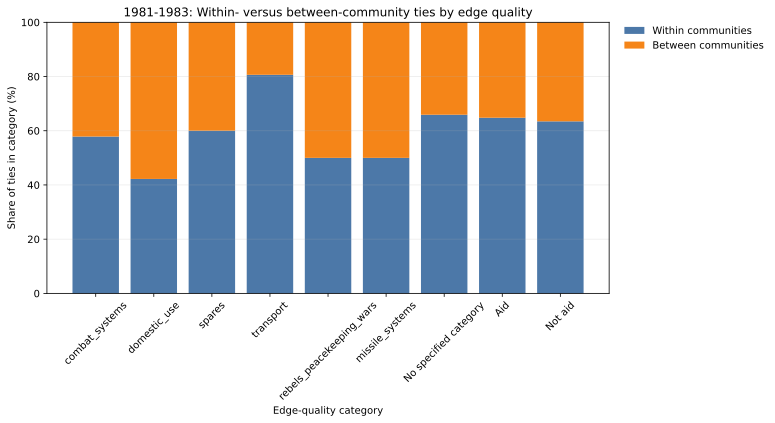

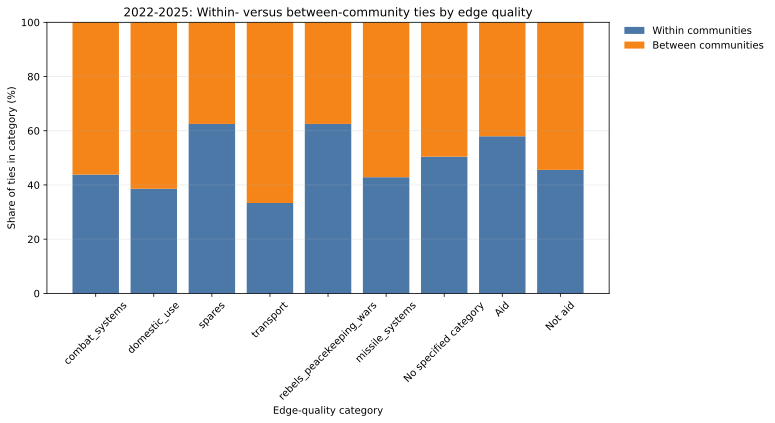

In [146]:
# Within- versus between-community ties by topic category and aid status.
def topic_label_map(topic_lookup):
    return dict(zip(topic_lookup["topic_col"], topic_lookup["topic_label"]))


def tie_topic_labels(row, topic_cols, topic_label_by_col):
    return [
        topic_label_by_col.get(topic_col, topic_col)
        for topic_col in topic_cols
        if row.get(topic_col, 0) == 1
    ]


def within_between_by_edge_quality(df, topic_cols, topic_lookup, include_no_topic=True):
    rows = []
    topic_label_by_col = topic_label_map(topic_lookup)

    def add_category_rows(category_label, category_type, subset):
        if subset.empty:
            return
        within_pct = subset["within_community"].mean() * 100
        rows.extend(
            [
                {
                    "category": category_label,
                    "category_type": category_type,
                    "relation": "Within community",
                    "pct": within_pct,
                    "n_ties": len(subset),
                },
                {
                    "category": category_label,
                    "category_type": category_type,
                    "relation": "Between community",
                    "pct": 100 - within_pct,
                    "n_ties": len(subset),
                },
            ]
        )

    for topic_col in topic_cols:
        add_category_rows(
            topic_label_by_col.get(topic_col, topic_col),
            "Topic",
            df[df[topic_col].eq(1)],
        )

    if include_no_topic:
        add_category_rows(
            "No specified category",
            "Topic",
            df[df["n_topics"].eq(0)],
        )

    for aid_value, aid_label in [(True, "Aid"), (False, "Not aid")]:
        add_category_rows(
            aid_label,
            "Aid status",
            df[df["aid"].eq(aid_value)],
        )

    return pd.DataFrame(rows)


def plot_within_between_by_edge_quality(df, period_label, topic_cols, topic_lookup):
    plot_df = within_between_by_edge_quality(df, topic_cols, topic_lookup)
    if plot_df.empty:
        print(f"No edge-quality categories available for {period_label}.")
        return plot_df

    category_order = plot_df.drop_duplicates("category")["category"].tolist()
    pivot_df = (
        plot_df.pivot(index="category", columns="relation", values="pct")
        .reindex(category_order)
        .fillna(0)
    )

    fig, ax = plt.subplots(figsize=(13, 6))
    ax.bar(
        pivot_df.index,
        pivot_df["Within community"],
        label="Within communities",
        color="#4c78a8",
    )
    ax.bar(
        pivot_df.index,
        pivot_df["Between community"],
        bottom=pivot_df["Within community"],
        label="Between communities",
        color="#f58518",
    )

    ax.set_title(f"{period_label}: Within- versus between-community ties by edge quality")
    ax.set_xlabel("Edge-quality category")
    ax.set_ylabel("Share of ties in category (%)")
    ax.set_ylim(0, 100)
    ax.tick_params(axis="x", rotation=45)
    ax.legend(
        frameon=False,
        loc="upper left",
        bbox_to_anchor=(1.02, 1),
        borderaxespad=0,
    )
    ax.grid(axis="y", alpha=0.25)
    plt.tight_layout(rect=[0, 0, 0.84, 1])
    plt.show()

    return plot_df


for period_label, period_df in structured_period_dfs.items():
    plot_within_between_by_edge_quality(
        period_df,
        period_label,
        topic_indicator_cols,
        topic_col_lookup,
    )


We see that between the two periods, the share of arms trades occurring across clear community lines seems to have decreased overall -- note, for example, the change in proportions in the arms deals belonging to "No specified category", which still make up the majority of our data. The same change (or no change) seems to occur broadly across most other types of arms deals, though the drop is most notable in deals that involve transport systems. One noticable exception is in arms trades done to support peacekeeping operations, wars, or anti-rebel efforts by recipient nations. The finding is surprising given the increased multipolarity and openness we saw elsewhere, both in this plot and the notebook at large. A look at the two period-specific FlowmapBlue visualizations produce earlier helps explain why, though. Whereas in the 1980s, most of the sales in that category occurred between the USSR and Jordan, presumably for peacekeeping in the 1980s Lebanon wars, the 2020s witnessed a more specific set of conflict-specififc arms trades related to the Russia-Ukraine conflict. It is in this category (i.e., when SIPRI coders could link an arms deal to a specific conflict) that we thus see how particular types of exchanges remain polarized even within an international order that, on the whole, has become more open and multipolar.

Building on the previous results, I next use **entropy** to examine how varied or concentrated the ties between communities are. For each period, I treat Louvain communities as nodes and aggregate all arms-trade ties between each pair of communities, ignoring tie direction. I then count the edge-quality categories attached to those ties: ties with no extracted topic are counted once as No specified category, while ties with multiple distinct topics contribute once to each topic category. Repeated instances of the same category on a single tie are counted only once.

For each community pair, these category counts are converted into shares that sum to 1, and I calculate Shannon entropy over that distribution. Low entropy means the relationship between two communities is dominated by one kind of tie quality (more 'unidimensional'); higher entropy means their relationship is more mixed across topics. The heatmaps display these entropy scores as a community-by-community matrix for each period.

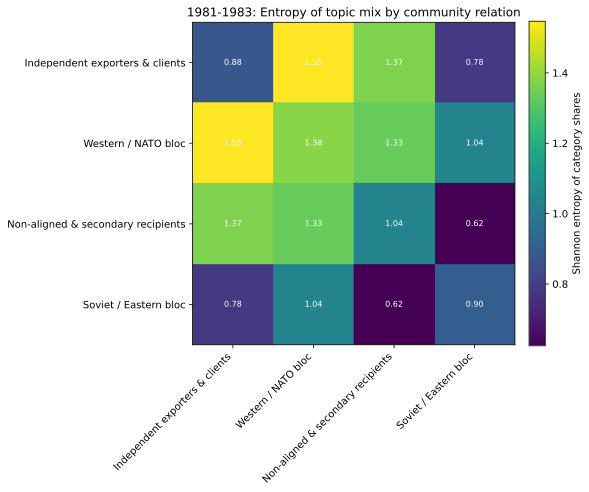

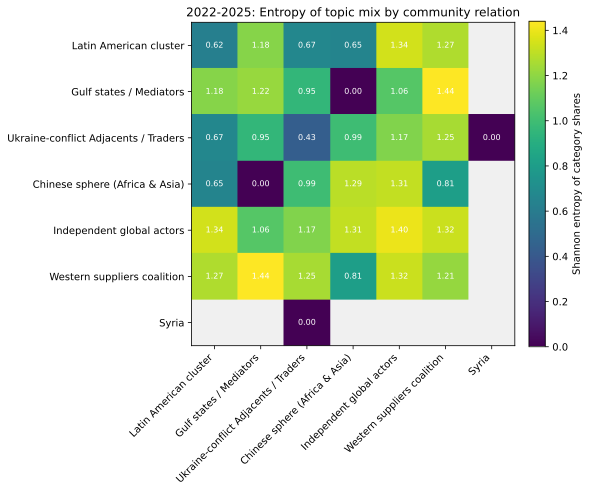

In [147]:
# Entropy of tie quality across undirected community relations.
def community_pair_topic_counts(df, period_label, topic_cols, topic_lookup):
    topic_label_by_col = topic_label_map(topic_lookup)
    valid_df = df.dropna(subset=["supplier_community", "recipient_community"]).copy()

    rows = []
    for _, row in valid_df.iterrows():
        supplier_community = int(row["supplier_community"])
        recipient_community = int(row["recipient_community"])
        community_a, community_b = sorted([supplier_community, recipient_community])

        tie_categories = tie_topic_labels(row, topic_cols, topic_label_by_col)
        if not tie_categories:
            tie_categories = ["No specified category"]

        for category in sorted(set(tie_categories)):
            rows.append(
                {
                    "period": period_label,
                    "community_a": community_a,
                    "community_b": community_b,
                    "community_a_label": format_community_label(period_label, community_a),
                    "community_b_label": format_community_label(period_label, community_b),
                    "category": category,
                    "category_count": 1,
                }
            )

    if not rows:
        return pd.DataFrame(
            columns=[
                "period",
                "community_a",
                "community_b",
                "community_a_label",
                "community_b_label",
                "category",
                "category_count",
            ]
        )

    return (
        pd.DataFrame(rows)
        .groupby(
            [
                "period",
                "community_a",
                "community_b",
                "community_a_label",
                "community_b_label",
                "category",
            ],
            as_index=False,
        )["category_count"]
        .sum()
    )


def community_pair_entropy(counts_df):
    if counts_df.empty:
        return counts_df.assign(total_count=[], category_share=[], entropy_component=[])

    entropy_df = counts_df.copy()
    entropy_df["total_count"] = entropy_df.groupby(
        ["period", "community_a", "community_b"]
    )["category_count"].transform("sum")
    entropy_df["category_share"] = entropy_df["category_count"] / entropy_df["total_count"]
    entropy_df["entropy_component"] = -entropy_df["category_share"] * np.log2(entropy_df["category_share"])

    return entropy_df


def entropy_matrix(entropy_components, period_label, community_ids):
    labels = [format_community_label(period_label, community_id) for community_id in community_ids]
    matrix = pd.DataFrame(np.nan, index=labels, columns=labels)

    entropy_by_pair = (
        entropy_components.groupby(["community_a", "community_b"], as_index=False)["entropy_component"]
        .sum()
        .rename(columns={"entropy_component": "entropy"})
    )

    for _, row in entropy_by_pair.iterrows():
        label_a = format_community_label(period_label, int(row["community_a"]))
        label_b = format_community_label(period_label, int(row["community_b"]))
        matrix.loc[label_a, label_b] = row["entropy"]
        matrix.loc[label_b, label_a] = row["entropy"]

    return matrix


def plot_entropy_heatmap(matrix, period_label):
    if matrix.empty:
        print(f"No community-pair entropy values available for {period_label}.")
        return

    cmap = plt.cm.viridis.copy()
    cmap.set_bad(color="#f0f0f0")

    fig, ax = plt.subplots(figsize=(8, 7))
    image = ax.imshow(matrix.to_numpy(dtype=float), cmap=cmap)
    ax.set_title(f"{period_label}: Entropy of topic mix by community relation")
    ax.set_xticks(range(len(matrix.columns)))
    ax.set_yticks(range(len(matrix.index)))
    ax.set_xticklabels(matrix.columns, rotation=45, ha="right")
    ax.set_yticklabels(matrix.index)

    for i in range(matrix.shape[0]):
        for j in range(matrix.shape[1]):
            value = matrix.iat[i, j]
            if pd.notna(value):
                ax.text(j, i, f"{value:.2f}", ha="center", va="center", color="white", fontsize=8)

    colorbar = fig.colorbar(image, ax=ax, fraction=0.046, pad=0.04)
    colorbar.set_label("Shannon entropy of category shares")
    plt.tight_layout()
    plt.show()


entropy_matrices = {}
for period_label, period_df in structured_period_dfs.items():
    counts_df = community_pair_topic_counts(
        period_df,
        period_label,
        topic_indicator_cols,
        topic_col_lookup,
    )
    entropy_components = community_pair_entropy(counts_df)
    community_ids = sorted(set(period_structures[period_label]["partition"].values()))
    matrix = entropy_matrix(entropy_components, period_label, community_ids)

    entropy_matrices[period_label] = matrix
    plot_entropy_heatmap(matrix, period_label)

No matter the period, actors that we'd expect to be the most deeply embedded in the international arms trade network (e.g., Western Bloc and Independent Dealers) have the highest level of entropy in their relations with other actors. Put differently, these actors may stand out as important or independent not only because of the volume of their trade, but also because they trade with others for a range of different reasons. In their dealings with each other, these groups of states unexpectedly also have some of the highest inter-group entropy measures in each period. In the 1980s, the group with the least diverse of cross-communal interactions was the Soviet / Eastern bloc, which could suggest a number of things - perhaps that they were more strategic in their approach to external arms trading, or that they placed an emphasis on self-reliance and independence from outside actors. Whether this emphasis on self-reliance could be linked to a less succesful Cold War outcome or not is beyond my purview as a sociologist, but could be worth investigating in an in-depth analysis. In the 2020s, no single group stands out as consistently atrophied in its international dealings as the Eastern bloc in the 1980s. However, the Latin American cluster does stand out as a group whose main variety in arms trades comes from an engagement with major Western suppliers and independent global actors. By contrast, their interactions with other groups seem more modest in variety, suggesting a more selective engagement with the global arms trades system and a stronger reliance on a small group of partners for their arms sales and procurements. Finally, Syria stands out due to its isolated position and having exchanged twice and solely with Turkey in the "Traders" group during the 2022-2025 period. 

Meanwhile, the 2020s witness the emergence of the Gulf States and other mediator countries a new pole with deep integration with Western partners and independent global actors. This new bloc, not visible in the 1980s, thus emerges as part of a new multipolar world, though it continues to be most deeply integrated with traditional power players. By contrast, it has a fairly _unidimensional_ engagement with states in the sphere of Chinese influence. This latter group instead shows more complex integration in its own rank and with independent arms exporting countries. Overall, these findings nuance picture of the multipolar world order by suggesting that a more fractured arms trade network does not directly translate into deep integration between all the new alliances involved. Instead, the newly emerged communities seem to continue in their reliance on powerful arms exporters for the full diversity of arms flows, while being more restrictive in the kinds of deals they have among each other.

For the final analysis, I investigated whether different brokerage positions in the arms-trade networkare associated with different edge-quality categories. This analysis was inspired by Stuhler's (2025) finding that actors central to literary narratives tend to have more ambiguous interactions with other characters and Gibson's (2005) argument that social interactions are patterned by the positions of actors in hierarchical networks. Each tie is assigned to its topic labels, plus Aid when applicable, and then grouped by supplier-recipient betweenness direction. The betweenness direction comes from period-specific actor tiers: high-betweenness actors are compared with mid/low-betweenness actors, producing High->Low, Low->High, or Similar ties. The code counts ties in each direction for every edge-quality category, converts those counts into within-category percentages, and plots grouped bar charts with category totals shown on the x-axis.

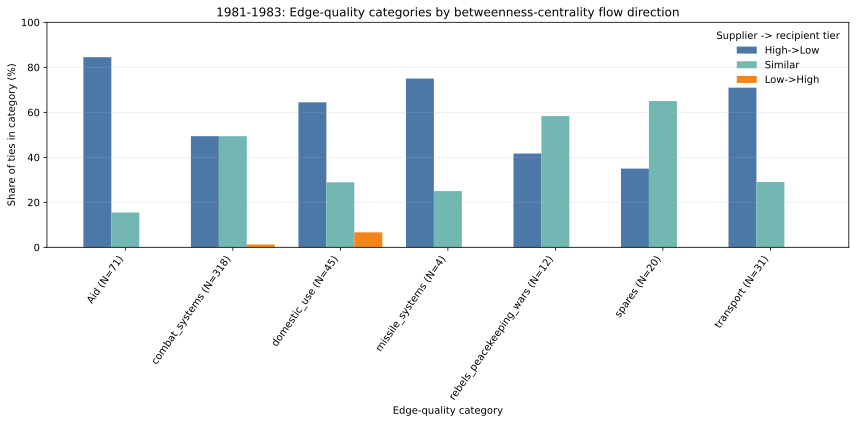

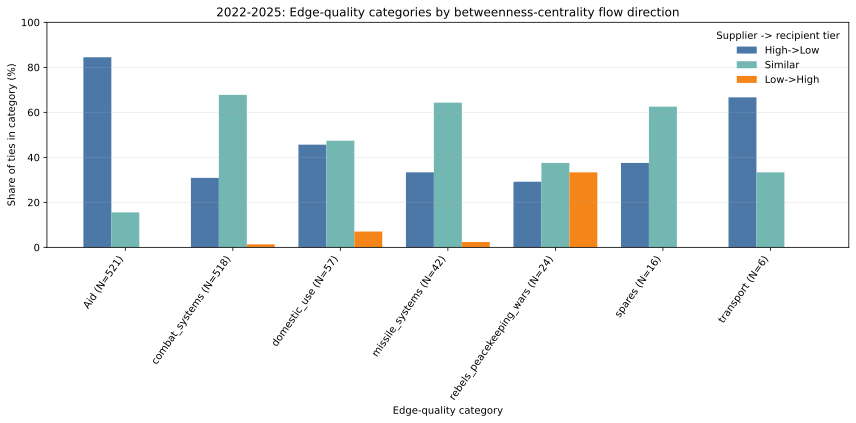

In [153]:
# Betweenness-tier flow direction by edge-quality category.
def expand_ties_by_flow_category(df, topic_cols, topic_lookup):
    topic_label_by_col = topic_label_map(topic_lookup)
    rows = []

    for _, row in df.iterrows():
        categories = tie_topic_labels(row, topic_cols, topic_label_by_col)
        if bool(row.get("aid", False)):
            categories.append("Aid")

        flow_group = str(row["bc_flow_group"])
        if flow_group not in {"High->Low", "Similar", "Low->High"}:
            continue

        for category in sorted(set(categories)):
            rows.append(
                {
                    "period": row["period"],
                    "edge_quality_category": category,
                    "bc_flow_group": flow_group,
                    "tie_count": 1,
                }
            )

    return pd.DataFrame(rows)


bc_category_flow_df = expand_ties_by_flow_category(
    structured_period_df,
    topic_indicator_cols,
    topic_col_lookup,
)

bc_category_flow_summary = (
    bc_category_flow_df.groupby(
        ["period", "edge_quality_category", "bc_flow_group"],
        as_index=False,
    )["tie_count"]
    .sum()
)
bc_category_flow_summary["category_total"] = bc_category_flow_summary.groupby(
    ["period", "edge_quality_category"]
)["tie_count"].transform("sum")
bc_category_flow_summary["pct_in_category"] = (
    bc_category_flow_summary["tie_count"] / bc_category_flow_summary["category_total"] * 100
)


def plot_bc_category_flow(summary_df, period_label):
    period_summary = summary_df[summary_df["period"].eq(period_label)].copy()
    if period_summary.empty:
        print(f"No betweenness-category flow data available for {period_label}.")
        return

    flow_order = ["High->Low", "Similar", "Low->High"]
    # Get category totals (for N display), but order categories alphabetically for plotting
    category_totals = (
        period_summary.groupby("edge_quality_category")["tie_count"]
        .sum()
    )
    # Order category labels alphabetically
    category_order = sorted(category_totals.index.tolist(), key=lambda x: str(x))
    x_labels = [f"{category} (N={int(category_totals.loc[category]):,})" for category in category_order]

    plot_matrix = pd.DataFrame(0.0, index=pd.Index(x_labels, name="category"), columns=flow_order)
    label_by_category = dict(zip(category_order, x_labels))
    for _, row in period_summary.iterrows():
        flow_group = str(row["bc_flow_group"])
        if flow_group not in flow_order:
            continue
        label = label_by_category[row["edge_quality_category"]]
        plot_matrix.loc[label, flow_group] = row["pct_in_category"]

    x = np.arange(len(plot_matrix.index))
    width = 0.26
    colors = {"High->Low": "#4c78a8", "Similar": "#72b7b2", "Low->High": "#f58518"}

    fig, ax = plt.subplots(figsize=(max(12, len(plot_matrix.index) * 0.9), 6))
    for offset, flow_group in zip([-width, 0, width], flow_order):
        ax.bar(
            x + offset,
            plot_matrix[flow_group],
            width=width,
            label=flow_group,
            color=colors[flow_group],
        )

    ax.set_title(f"{period_label}: Edge-quality categories by betweenness-centrality flow direction")
    ax.set_xlabel("Edge-quality category")
    ax.set_ylabel("Share of ties in category (%)")
    ax.set_ylim(0, 100)
    ax.set_xticks(x)
    ax.set_xticklabels(plot_matrix.index, rotation=55, ha="right")
    ax.legend(title="Supplier -> recipient tier", frameon=False)
    ax.grid(axis="y", alpha=0.25)
    plt.tight_layout()
    plt.show()


for period_label in structured_period_dfs:
    plot_bc_category_flow(bc_category_flow_summary, period_label)


The barcharts helps us ask what kinds of exchanges happen between what kinds of actors. Aid, for example, invariably and overwhelmingly comes from central brokers toward less central actors. Combat system, by contrast are more likely to be exchanged between actors in similarly central positions, especially in 2022. Indeed, the barchart suggests that in more recent years, most types of exchanges became more likely between states in comparable centrality positions, with the exception of aid (seems to be the resilient purview of 'powerful' actors favoring 'weaker' states in need), spares (already likely between states in similar centrality positions in the 1980s, perhaps enabled through the possession of similar weapons systems whose parts could be exchanged), and transport systems (small number in 2020s may not be very informative of larger trends, though). One notable change is the sudden trade of weapons for specific wars from low- to higher-centrality states in 2022. Looking at the FlowmapBlue maps, that switch is caused by North Koreas sudden role as an arms supplier for Russia in its invasion of Ukraine, which suddenly put a highly marginal actor in a supplier position for a more centrally positioned one. The rarity of such supplier relations in other types of exchanges underscores the exceptional position Russia found itself in following the invasion, as it had to rely on any source it could to find supplies after its plan for a quick takeover failed.

To conclude, then, I have shown how the analysis of edge quality can help us make better sense of structure in the international network of weapons flows. Specifically, my findings reveal how the Ukraine-Russia conflict is embedded in the new multipolar world order of the 21st century. In this setup, the world is more fractured and less reliant on a small set of central power brokers. Yet my findings also show how the _integration_ of these newly emergent factions varies, with powerful exporters remaining the source of _variety_ in international arms trades. Finally, my findings also suggest that the Ukraine-Russia conflict differed to the Cold War due to the more explicit reliance on _aid_ in weapons transfers, a category which the 'cold' nature of the previous geopolitical contest may have obscured. That is, weapons transfers during the Cold War may have been organized according to strategic targets by both the US and the USSR, but the passive nature of the conflict may have promoted the obfuscation of such motives, prevented arms sales from being explicitly labelled as 'aid', or obviated the need for this category when the countries did in fact get directly involved such as the USA in the Vietnam war.

My analyses certainly do not exhaust the range of potential investigations afforded by this theoretical orientation, and several questions remain. For example, what kinds of arm sales tend to appear together in the relationships between countries and communities? How are these arms flows patterned outside of conflict periods, such as during the comparatively less conflictual period of U.S. hegemony immediately after the disintegration of the USSR? Bringing other methods to bear on this data may also yield more detailed insights than my rudimentary data extraction methods could afford -- for example, linking the names of weapons systems to specific classes (e.g., fireweapons, material or troop transporters, etc.) or military uses (e.g., intelligence gathering, naval defense, etc.) could shed further light on the kinds of interlinkages that make up the international arms trade networks. In line with the interdisciplinary outlook of this class, the current project represents less of a final answer to any particular question and (or so I hope) more of a primer on the fruitful possibilities that the applications of concepts from sociology could yield in the world of international politics.

# Bibliography

Fuhse, Jan A. “The Meaning Structure of Social Networks.” Sociological Theory 27, no. 1 (2009): 51–73. https://doi.org/10.1111/j.1467-9558.2009.00338.x.

Gibson, David R. “Taking Turns and Talking Ties: Networks and Conversational Interaction.” American Journal of Sociology 110, no. 6 (2005): 1561–97. https://doi.org/10.1086/428689.

Gondal, Neha. “Multiplexity as a Lens to Investigate the Cultural Meanings of Interpersonal Ties.” Social Networks 68 (January 2022): 209–17. https://doi.org/10.1016/j.socnet.2021.07.002.

Padgett, John F., and Christopher K. Ansell. “Robust Action and the Rise of the Medici, 1400-1434.” American Journal of Sociology 98, no. 6 (1993): 1259–319. https://doi.org/10.1086/230190.

Stuhler, Oscar. “The Cultural Construction of Personal Relationships.” Social Networks 83 (October 2025): 199–214. https://doi.org/10.1016/j.socnet.2025.07.001.


# A.I. Disclaimer
Several parts of this notebook were generated with AI. Though the course syllabus does not address the use of AI in class or for the final project specifically, I'll follow the best practices I learned in other classes and put down a brief description of my AI usage during coding.

Most of the code was generated with AI through an iterative process. First, I sketched out the data processing steps, analyses, and plots I wanted to achieve for individual sections (e.g., NLP) of the project. For each part, I would think through the details that would have to be executed one way or another to achieve the sort of results I was aiming for (e.g., how to aggregate the types of ties present in inter-community relations for the final entropy analysis, or plotting details for visualizations). This step often included some manual data exploration and testing to get a better sense of the points an LLM would need to be informed of during coding. Sometimes, I would sketch out a skeleton approach for the code over multiple cells as a way of supporting the code implemention. I would then describe my designs and target locations to an LLM in as much detail as possible to ensure it would implement the approach as I had planned them. Using Cursor and a blend of the native Composer 2.5 model as well as GPT 5.5, I would then let the LLM design a code plan, a process during which I asked it to clarify open questions with  me should they remain. Once I was satisfied with the code plan, I would let the LLM execute the plan and finally tested and iteratively refined the code until the output was to my liking. Before submission, I also advised an LLM to iterate over the notebook and remove redundant code that may have accumulated during my work on the project. All the writing in this notebook remain my own and I take full ownership and responsibility for the results hereby submitted.